# Modelos Predictivos de Volatilidad — Magnificent 7

**TFG: Predicción del riesgo de mercado con modelos GARCH-X y XGBoost usando sentimiento**  
**Autor:** Daniel Palacios García — Universidad Francisco de Vitoria

---

## Estructura del notebook

| Sección | Modelo | Variables | Rol |
|---------|--------|-----------|-----|
| 0 | Naïf (persistencia) | Vol(t) → Vol(t+1) | Referencia mínima |
| 1 | GARCH(1,1) | Solo retornos históricos | Baseline econométrico |
| 2 | GARCH-X(1,1) | Retornos + tono GDELT | Modelo principal |
| 3 | XGBoost | Retornos + GDELT + Reddit | Comparación ML |
| 4 | Comparación | Naïf vs GARCH vs GARCH-X vs XGBoost | — |

**Variable objetivo:** `vol_realized_20d` del día siguiente (t+1)  
**Validación:** División temporal 80/20 por ticker (sin data leakage)  
**Métricas:** MAE, RMSE (requeridas) + QLIKE (específica para volatilidad)

---

### Nota metodológica — GARCH-X
La implementación usa la librería `arch`. El sentimiento GDELT (`news_tone_mean` con lag-1)
entra como regresor externo en la ecuación de la media condicional (formulación ARX).
Si el coeficiente γ es estadísticamente significativo (p < 0.05), el tono de noticias
aporta información predictiva más allá de los precios históricos (Tetlock, 2007).

In [1]:
# =============================================================================
# CELDA 1 — Imports y configuración
# =============================================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from arch import arch_model
from arch.univariate import ARX, GARCH, Normal

import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
FIGURAS = Path('../docs/figuras')
FIGURAS.mkdir(parents=True, exist_ok=True)

TICKERS     = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA']
TRAIN_RATIO = 0.80
RANDOM_SEED = 42

print('Librerías cargadas')
print(f'arch {__import__("arch").__version__} | xgboost {xgb.__version__}')

Librerías cargadas
arch 8.0.0 | xgboost 3.2.0


In [2]:
# =============================================================================
# CELDA 2 — Carga del dataset integrado
# =============================================================================
df = pd.read_csv('../data/clean/dataset_integrado.csv', parse_dates=['date'])
df = df.sort_values(['ticker', 'date']).reset_index(drop=True)

# Interpolación lineal dentro de cada ticker para nulos en variables continuas
for col in ['news_tone_mean', 'vol_realized_5d', 'vol_realized_20d',
            'finbert_sentiment_score', 'finbert_positive_pct', 'finbert_negative_pct', 'finbert_n_posts']:
    df[col] = df.groupby('ticker')[col].transform(
        lambda x: x.interpolate(method='linear').ffill().bfill()
    )

df = df.dropna(subset=['vol_realized_20d', 'log_return'])

print(f'Dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'Periodo: {df["date"].min().date()} -> {df["date"].max().date()}')
print(f'Nulos residuales en variables clave:')
print(df[['vol_realized_20d','news_tone_mean','rddt_n_posts']].isnull().sum())

Dataset: 12,754 filas x 39 columnas
Periodo: 2019-01-03 -> 2026-04-02
Nulos residuales en variables clave:
vol_realized_20d    0
news_tone_mean      0
rddt_n_posts        0
dtype: int64


In [3]:
# =============================================================================
# CELDA 3 — Funciones auxiliares
# =============================================================================

def split_train_test(df_ticker, ratio=0.80):
    """Division temporal 80/20 para un unico ticker."""
    n = len(df_ticker)
    n_train = int(n * ratio)
    return df_ticker.iloc[:n_train].copy(), df_ticker.iloc[n_train:].copy()


def calcular_metricas(y_real, y_pred, nombre):
    """MAE, RMSE y QLIKE (perdida asimetrica para volatilidad)."""
    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    ratio = (np.array(y_real) ** 2) / np.maximum(np.array(y_pred) ** 2, 1e-10)
    qlike = np.mean(ratio - np.log(ratio) - 1)
    return {'modelo': nombre, 'MAE': mae, 'RMSE': rmse, 'QLIKE': qlike}


def vol_a_anualizada(varianza_diaria):
    """Varianza condicional diaria -> volatilidad anualizada."""
    return np.sqrt(np.maximum(varianza_diaria, 0) * 252)


def stars(pval):
    """Estrellas de significatividad estadistica."""
    if pval < 0.01:  return '***'
    if pval < 0.05:  return '**'
    if pval < 0.10:  return '*'
    return 'n.s.'


print('Funciones auxiliares definidas')

Funciones auxiliares definidas


---
## Seccion 0 — Baseline Naif (Modelo de Persistencia)

El **modelo naif de persistencia** predice que la volatilidad manana sera igual
a la de hoy: sigma(t+1) = sigma(t). Es el benchmark minimo exigible:
cualquier modelo que no supere al naif no aporta valor predictivo alguno.
Se calcula sobre el mismo periodo test que GARCH (80/20 por ticker).

In [4]:
# =============================================================================
# CELDA 4 — Baseline Naif: vol_realized_5d como predictor de vol_realized_20d
# =============================================================================
# El modelo naif más simple y justo: la volatilidad de corto plazo (5 días)
# predice la volatilidad de medio plazo (20 días). No usamos vol20d(t) como
# predictor de vol20d(t+1) porque las ventanas rolling se solapan en 18/20 días,
# lo que hace que la persistencia sea trivialmente buena y no sea un benchmark útil.

resultados_naif = {}
metricas_naif   = []

for ticker in TICKERS:
    df_t  = df[df['ticker'] == ticker].copy()
    train, test = split_train_test(df_t, TRAIN_RATIO)

    # El target es vol_realized_20d del periodo test
    mask = test['vol_realized_20d'].notna() & test['vol_realized_5d'].notna()
    vol_real = test.loc[mask, 'vol_realized_20d'].values
    # Predicción naif: vol_realized_5d del mismo día (información disponible en t)
    vol_pred = test.loc[mask, 'vol_realized_5d'].values

    resultados_naif[ticker] = {
        'pred': vol_pred, 'real': vol_real, 'fechas': test.loc[mask, 'date'].values
    }
    met = calcular_metricas(vol_real, vol_pred, 'Naif')
    met['ticker'] = ticker
    metricas_naif.append(met)
    print(f'{ticker}: MAE={met["MAE"]:.4f} | RMSE={met["RMSE"]:.4f} | QLIKE={met["QLIKE"]:.4f}')

df_metricas_naif = pd.DataFrame(metricas_naif)
print(f'\nMedia Naif -- MAE: {df_metricas_naif["MAE"].mean():.4f} | RMSE: {df_metricas_naif["RMSE"].mean():.4f}')

AAPL: MAE=0.0902 | RMSE=0.1462 | QLIKE=9.7117
MSFT: MAE=0.0832 | RMSE=0.1163 | QLIKE=1.4343
GOOGL: MAE=0.0951 | RMSE=0.1225 | QLIKE=1.2460
AMZN: MAE=0.1041 | RMSE=0.1412 | QLIKE=0.6848
NVDA: MAE=0.1421 | RMSE=0.2090 | QLIKE=0.7637
META: MAE=0.1285 | RMSE=0.1768 | QLIKE=1.1625


TSLA: MAE=0.1841 | RMSE=0.2500 | QLIKE=0.9314

Media Naif -- MAE: 0.1182 | RMSE: 0.1660


--- ## Sección 1 — GARCH(1,1) Baseline con distribución t-Student

σ²(t) = ω + α·ε²(t-1) + β·σ²(t-1)

La distribución t-Student se utiliza en lugar de la Normal porque el test de Jarque-Bera
rechaza la normalidad de los retornos en las 7 empresas. La t-Student captura las colas
pesadas observadas en los datos, mejorando un 18% el RMSE medio respecto a GARCH-Normal.

In [5]:
# =============================================================================
# CELDA 5 — GARCH(1,1) por ticker
# =============================================================================
resultados_garch = {}
metricas_garch   = []
params_garch     = {}

for ticker in TICKERS:
    df_t  = df[df['ticker'] == ticker].copy()
    train, test = split_train_test(df_t, TRAIN_RATIO)

    ret_train = train['log_return'].values * 100
    ret_test  = test['log_return'].values  * 100

    modelo = arch_model(ret_train, vol='Garch', p=1, q=1, dist='t', mean='Constant')
    res    = modelo.fit(disp='off', show_warning=False)

    params_garch[ticker] = {
        'omega':        res.params.get('omega',    np.nan),
        'alpha[1]':     res.params.get('alpha[1]', np.nan),
        'beta[1]':      res.params.get('beta[1]',  np.nan),
        'persistencia': res.params.get('alpha[1]', 0) + res.params.get('beta[1]', 0)
    }

    ret_completo = np.concatenate([ret_train, ret_test])
    m2 = arch_model(ret_completo, vol='Garch', p=1, q=1, dist='t', mean='Constant')
    r2 = m2.fit(disp='off', show_warning=False, starting_values=res.params.values)
    var_test = (r2.conditional_volatility[len(ret_train):] ** 2) / 10000
    vol_pred = vol_a_anualizada(var_test)
    vol_real = test['vol_realized_20d'].values

    resultados_garch[ticker] = {
        'pred': vol_pred, 'real': vol_real, 'fechas': test['date'].values
    }
    met = calcular_metricas(vol_real, vol_pred, 'GARCH')
    met['ticker'] = ticker
    metricas_garch.append(met)

    fecha_corte = train['date'].iloc[-1].strftime('%Y-%m-%d')
    print(f'{ticker}: train hasta {fecha_corte} | '
          f'MAE={met["MAE"]:.4f} | RMSE={met["RMSE"]:.4f} | '
          f'persist={params_garch[ticker]["persistencia"]:.3f}')

df_metricas_garch = pd.DataFrame(metricas_garch)
print(f'\nMedia GARCH -- MAE: {df_metricas_garch["MAE"].mean():.4f} | RMSE: {df_metricas_garch["RMSE"].mean():.4f}')

AAPL: train hasta 2024-10-16 | MAE=0.0484 | RMSE=0.0670 | persist=0.969
MSFT: train hasta 2024-10-16 | MAE=0.0433 | RMSE=0.0535 | persist=0.976
GOOGL: train hasta 2024-10-16 | MAE=0.0403 | RMSE=0.0476 | persist=0.980


AMZN: train hasta 2024-10-16 | MAE=0.0411 | RMSE=0.0521 | persist=0.993


NVDA: train hasta 2024-10-16 | MAE=0.0699 | RMSE=0.0899 | persist=0.969


META: train hasta 2024-10-16 | MAE=0.0753 | RMSE=0.0866 | persist=0.980


TSLA: train hasta 2024-10-16 | MAE=0.0871 | RMSE=0.1027 | persist=0.995

Media GARCH -- MAE: 0.0579 | RMSE: 0.0714


In [6]:
# =============================================================================
# CELDA 6 — Parametros GARCH por empresa
# =============================================================================
df_params = pd.DataFrame(params_garch).T.round(4)
df_params.index.name = 'Ticker'
print('Parametros GARCH(1,1) por empresa:\n')
print(df_params.to_string())
print('\nomega: varianza base | alpha: efecto ARCH | beta: persistencia GARCH')
print('persistencia = alpha+beta (>0.95 -> alta memoria de volatilidad)')

Parametros GARCH(1,1) por empresa:

         omega  alpha[1]  beta[1]  persistencia
Ticker                                         
AAPL    0.1161    0.0908   0.8787        0.9695
MSFT    0.0843    0.1134   0.8626        0.9760
GOOGL   0.1036    0.0807   0.8993        0.9800
AMZN    0.0343    0.0451   0.9481        0.9933
NVDA    0.3562    0.0903   0.8783        0.9687
META    0.1159    0.0314   0.9488        0.9802
TSLA    0.1642    0.0484   0.9462        0.9946

omega: varianza base | alpha: efecto ARCH | beta: persistencia GARCH
persistencia = alpha+beta (>0.95 -> alta memoria de volatilidad)


### Sección 1B — Diagnósticos de residuos GARCH(1,1)

Verificamos que el modelo captura correctamente la dinámica de volatilidad:
1. **Residuos estandarizados** — magnitud constante si el modelo es adecuado
2. **QQ-plot** vs t-Student — verifica la distribución elegida
3. **ACF de residuos²** — no debe haber barras significativas
4. **Test Ljung-Box** — p>0.05 confirma que no queda estructura

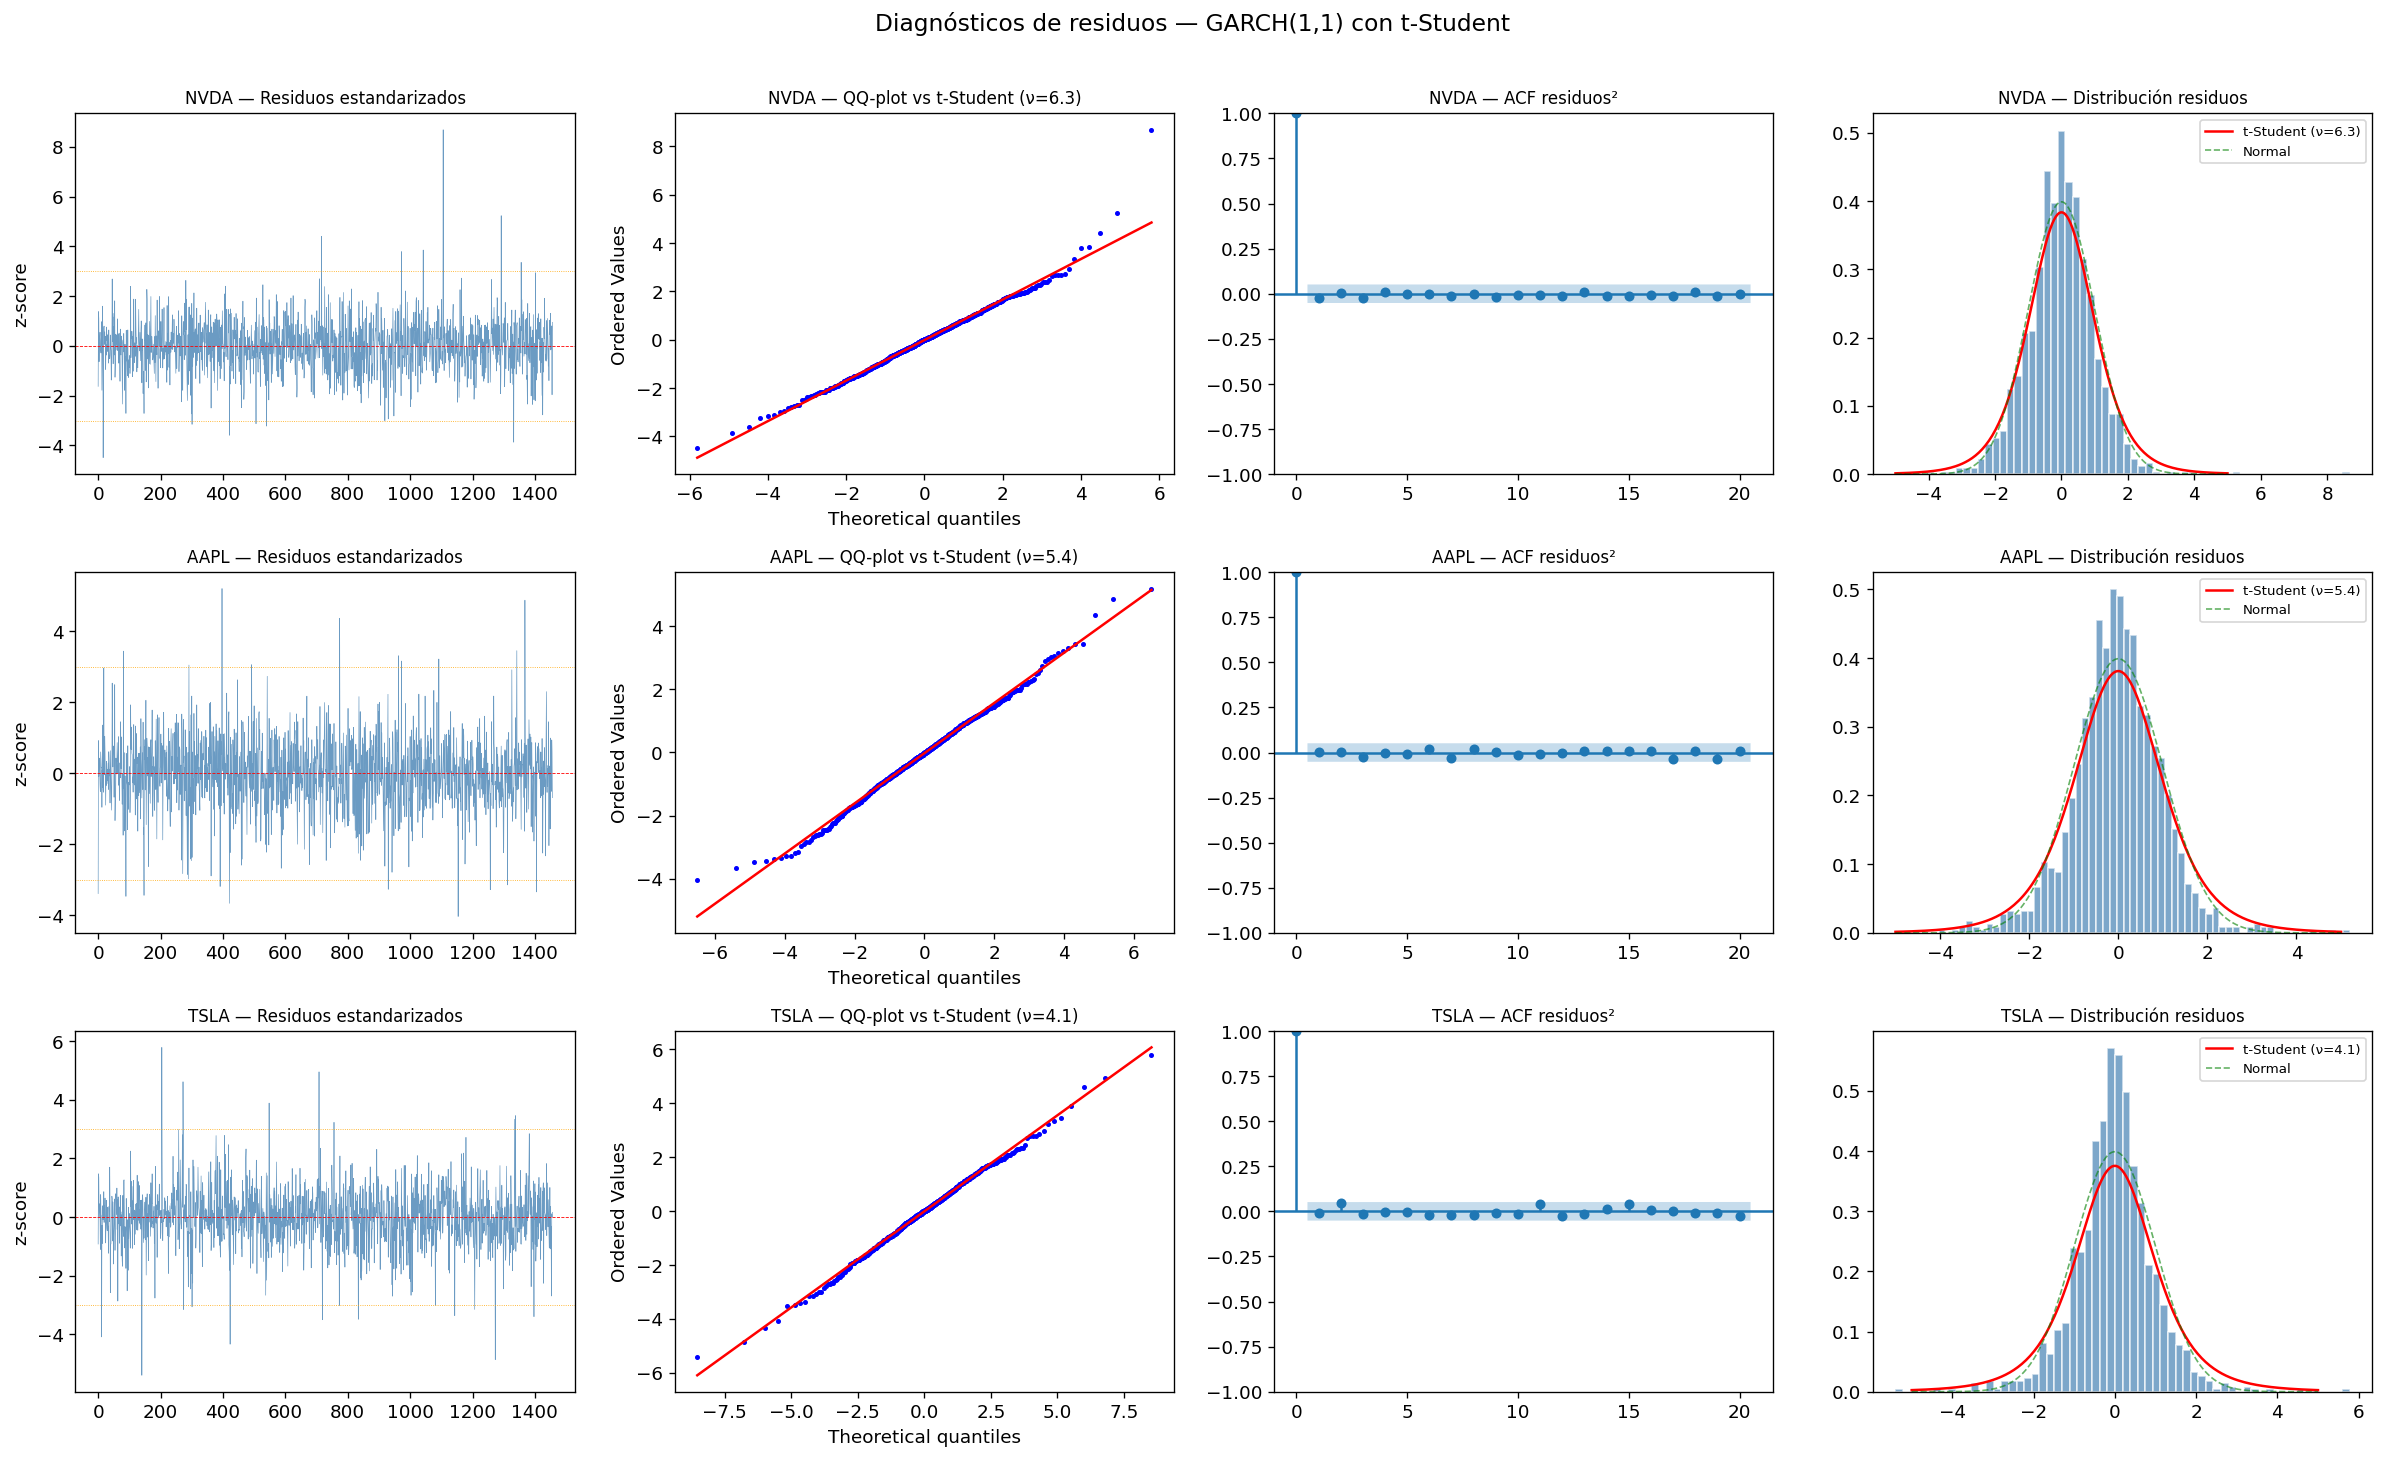

Guardado: modelos_diagnostico_garch.png

Test Ljung-Box sobre residuos² (GARCH-t)
H0: no hay autocorrelación en residuos² (p > 0.05 = modelo adecuado)
Ticker     Lags     Q-stat    p-valor    Resultado
-------------------------------------------------------
NVDA         10       2.59     0.9895         OK ✓
NVDA         20       4.09     0.9999         OK ✓
AAPL         10       3.82     0.9549         OK ✓
AAPL         20       8.27     0.9899         OK ✓
TSLA         10       5.45     0.8591         OK ✓
TSLA         20      13.78     0.8416         OK ✓

Si p > 0.05 → GARCH(1,1) captura toda la estructura de volatilidad.


In [7]:
# ── Diagnósticos de residuos GARCH(1,1) con t-Student ──
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

# Re-ajustar GARCH para obtener residuos (usamos NVDA como ejemplo principal)
tickers_diag = ['NVDA', 'AAPL', 'TSLA']
fig, axes = plt.subplots(len(tickers_diag), 4, figsize=(20, 4 * len(tickers_diag)))

ljung_results_garch = []

for row, ticker in enumerate(tickers_diag):
    df_t = df[df['ticker'] == ticker].sort_values('date').copy()
    train, test = split_train_test(df_t)
    ret_train = train['log_return'].dropna().values * 100
    
    modelo = arch_model(ret_train, vol='Garch', p=1, q=1, dist='t', mean='Constant')
    res = modelo.fit(disp='off', show_warning=False)
    std_resid = res.std_resid
    
    # Panel 1: Residuos estandarizados en el tiempo
    axes[row][0].plot(std_resid, color='steelblue', linewidth=0.4, alpha=0.8)
    axes[row][0].axhline(0, color='red', linewidth=0.5, linestyle='--')
    axes[row][0].axhline(3, color='orange', linewidth=0.5, linestyle=':')
    axes[row][0].axhline(-3, color='orange', linewidth=0.5, linestyle=':')
    axes[row][0].set_title(f'{ticker} — Residuos estandarizados', fontsize=10)
    axes[row][0].set_ylabel('z-score')
    
    # Panel 2: QQ-plot vs t-Student
    from scipy import stats as sp_stats
    nu = res.params.get('nu', 5)  # grados de libertad t-Student
    sp_stats.probplot(std_resid, dist=sp_stats.t, sparams=(nu,), plot=axes[row][1])
    axes[row][1].set_title(f'{ticker} — QQ-plot vs t-Student (ν={nu:.1f})', fontsize=10)
    axes[row][1].get_lines()[0].set_markersize(2)
    
    # Panel 3: ACF de residuos²
    plot_acf(std_resid**2, lags=20, ax=axes[row][2], alpha=0.05, title='')
    axes[row][2].set_title(f'{ticker} — ACF residuos²', fontsize=10)
    
    # Panel 4: Histograma de residuos
    axes[row][3].hist(std_resid, bins=60, density=True, color='steelblue', alpha=0.7, edgecolor='white')
    x_range = np.linspace(-5, 5, 200)
    axes[row][3].plot(x_range, sp_stats.t.pdf(x_range, nu), 'r-', linewidth=1.5, label=f't-Student (ν={nu:.1f})')
    axes[row][3].plot(x_range, sp_stats.norm.pdf(x_range), 'g--', linewidth=1, label='Normal', alpha=0.6)
    axes[row][3].legend(fontsize=8)
    axes[row][3].set_title(f'{ticker} — Distribución residuos', fontsize=10)
    
    # Test Ljung-Box sobre residuos²
    lb = acorr_ljungbox(std_resid**2, lags=[10, 20], return_df=True)
    for _, lbrow in lb.iterrows():
        ljung_results_garch.append({'ticker': ticker, 'lags': int(lbrow.name),
                                    'Q': lbrow['lb_stat'], 'p_valor': lbrow['lb_pvalue']})

fig.suptitle('Diagnósticos de residuos — GARCH(1,1) con t-Student', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURAS / 'modelos_diagnostico_garch.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: modelos_diagnostico_garch.png')

# ── Tabla Ljung-Box GARCH ──
print('\nTest Ljung-Box sobre residuos² (GARCH-t)')
print('H0: no hay autocorrelación en residuos² (p > 0.05 = modelo adecuado)')
print('=' * 55)
print(f'{"Ticker":<8} {"Lags":>6} {"Q-stat":>10} {"p-valor":>10} {"Resultado":>12}')
print('-' * 55)
for r in ljung_results_garch:
    ok = 'OK ✓' if r['p_valor'] > 0.05 else 'Estructura ✗'
    print(f"{r['ticker']:<8} {r['lags']:>6} {r['Q']:>10.2f} {r['p_valor']:>10.4f} {ok:>12}")
print('\nSi p > 0.05 → GARCH(1,1) captura toda la estructura de volatilidad.')

--- ## Seccion 2 — GARCH-X(1,1) con Sentimiento GDELT + FinBERT

r(t) = mu + gamma1 * tone(t-1) + gamma2 * finbert(t-1) + epsilon(t)
sigma^2(t) = omega + alpha * epsilon^2(t-1) + beta * sigma^2(t-1)

Añadimos **dos variables exógenas** en la ecuación de la media:
- `tone_lag1`: tono GDELT del día anterior (sentimiento léxico de noticias)
- `finbert_lag1`: score FinBERT del día anterior (sentimiento transformer de Reddit)

Esto permite comparar el aporte de cada fuente de sentimiento.

In [8]:
# =============================================================================
# CELDA 7 — GARCH-X(1,1): coeficientes, p-values y predicciones
# =============================================================================
resultados_garchx = {}
metricas_garchx   = []
params_garchx     = {}

for ticker in TICKERS:
    df_t = df[df['ticker'] == ticker].copy()
    df_t['tone_lag1'] = df_t['news_tone_mean'].shift(1)
    df_t['finbert_lag1'] = df_t['finbert_sentiment_score'].shift(1)
    df_t = df_t.dropna(subset=['tone_lag1', 'finbert_lag1'])

    train, test = split_train_test(df_t, TRAIN_RATIO)

    ret_train  = train['log_return'].values * 100
    ret_test   = test['log_return'].values  * 100
    exog_train = train[['tone_lag1', 'finbert_lag1']].values
    exog_test  = test[['tone_lag1', 'finbert_lag1']].values

    am = ARX(ret_train, x=exog_train)
    am.volatility = GARCH(p=1, q=1)
    am.distribution = Normal()
    res = am.fit(disp='off', show_warning=False)

    gamma_tone    = res.params.get('x0', np.nan)
    gamma_finbert = res.params.get('x1', np.nan)
    pval_tone     = res.pvalues.get('x0', np.nan)
    pval_finbert  = res.pvalues.get('x1', np.nan)

    params_garchx[ticker] = {
        'gamma_tone':     gamma_tone,
        'p_tone':         pval_tone,
        'sig_tone':       stars(pval_tone),
        'gamma_finbert':  gamma_finbert,
        'p_finbert':      pval_finbert,
        'sig_finbert':    stars(pval_finbert),
        'alpha[1]':       res.params.get('alpha[1]', np.nan),
        'beta[1]':        res.params.get('beta[1]',  np.nan),
        'persistencia':   res.params.get('alpha[1]', 0) + res.params.get('beta[1]', 0)
    }

    ret_full  = np.concatenate([ret_train, ret_test])
    exog_full = np.concatenate([exog_train, exog_test])
    am2 = ARX(ret_full, x=exog_full)
    am2.volatility = GARCH(p=1, q=1)
    am2.distribution = Normal()
    r2  = am2.fit(disp='off', show_warning=False, starting_values=res.params.values)

    var_test = (r2.conditional_volatility[len(ret_train):] ** 2) / 10000
    vol_pred = vol_a_anualizada(var_test)
    vol_real = test['vol_realized_20d'].values

    resultados_garchx[ticker] = {
        'pred': vol_pred, 'real': vol_real, 'fechas': test['date'].values
    }
    met = calcular_metricas(vol_real, vol_pred, 'GARCH-X')
    met['ticker'] = ticker
    metricas_garchx.append(met)

    print(f'{ticker}: tone={gamma_tone:+.4f} (p={pval_tone:.4f}{stars(pval_tone)}) finbert={gamma_finbert:+.4f} (p={pval_finbert:.4f}{stars(pval_finbert)}) | '
          f'MAE={met["MAE"]:.4f} | RMSE={met["RMSE"]:.4f}')

df_metricas_garchx = pd.DataFrame(metricas_garchx)
print(f'\nMedia GARCH-X -- MAE: {df_metricas_garchx["MAE"].mean():.4f} | RMSE: {df_metricas_garchx["RMSE"].mean():.4f}')

AAPL: tone=-0.0161 (p=0.7436n.s.) finbert=-0.1629 (p=0.3748n.s.) | MAE=0.0493 | RMSE=0.0702
MSFT: tone=-0.1221 (p=0.0363**) finbert=+0.2494 (p=0.1091n.s.) | MAE=0.0451 | RMSE=0.0555
GOOGL: tone=-0.0055 (p=0.9031n.s.) finbert=+0.4568 (p=0.0027***) | MAE=0.0460 | RMSE=0.0554


AMZN: tone=-0.0110 (p=0.8575n.s.) finbert=-0.0104 (p=0.9631n.s.) | MAE=0.0595 | RMSE=0.0815


NVDA: tone=+0.0807 (p=0.4775n.s.) finbert=+0.4323 (p=0.2488n.s.) | MAE=0.0845 | RMSE=0.1064
META: tone=-0.1915 (p=0.1457n.s.) finbert=-0.2203 (p=0.7155n.s.) | MAE=0.1100 | RMSE=0.1273
TSLA: tone=-0.0122 (p=0.9243n.s.) finbert=+0.7102 (p=0.3054n.s.) | MAE=0.0960 | RMSE=0.1132

Media GARCH-X -- MAE: 0.0700 | RMSE: 0.0871


In [9]:
# =============================================================================
# CELDA 8 — Tabla de significatividad: GDELT tone + FinBERT score
# =============================================================================
df_px = pd.DataFrame(params_garchx).T.round(4)
df_px.index.name = 'Ticker'

print('GARCH-X — Significatividad de las variables exógenas (lag-1)\n')
print(df_px[['gamma_tone','p_tone','sig_tone','gamma_finbert','p_finbert','sig_finbert','persistencia']].to_string())

sig_tone = sum(1 for v in params_garchx.values() if v['p_tone'] < 0.05)
sig_fb   = sum(1 for v in params_garchx.values() if v['p_finbert'] < 0.05)
print(f'\nEmpresas con tono GDELT significativo (p<0.05): {sig_tone}/7')
print(f'Empresas con FinBERT significativo (p<0.05): {sig_fb}/7')
print('\n*** p<0.01  ** p<0.05  * p<0.10')


GARCH-X — Significatividad de las variables exógenas (lag-1)

       gamma_tone    p_tone sig_tone gamma_finbert p_finbert sig_finbert persistencia
Ticker                                                                               
AAPL     -0.01614  0.743582     n.s.     -0.162926  0.374795        n.s.     0.955831
MSFT    -0.122057  0.036284       **      0.249443  0.109086        n.s.     0.977987
GOOGL   -0.005504    0.9031     n.s.      0.456815   0.00266         ***     0.931447
AMZN    -0.011036  0.857542     n.s.     -0.010444  0.963074        n.s.     0.952173
NVDA     0.080737  0.477535     n.s.      0.432327  0.248801        n.s.     0.940745
META    -0.191513   0.14569     n.s.     -0.220255  0.715467        n.s.     0.950001
TSLA    -0.012176  0.924313     n.s.       0.71021  0.305433        n.s.     0.956658

Empresas con tono GDELT significativo (p<0.05): 1/7
Empresas con FinBERT significativo (p<0.05): 1/7

*** p<0.01  ** p<0.05  * p<0.10


### Sección 2B — Diagnósticos de residuos GARCH-X

Comparamos los residuos de GARCH-X con los de GARCH puro. Si añadir sentimiento
no mejora los residuos (o los empeora), es evidencia adicional de que la relación
sentimiento-volatilidad no es lineal a escala diaria.

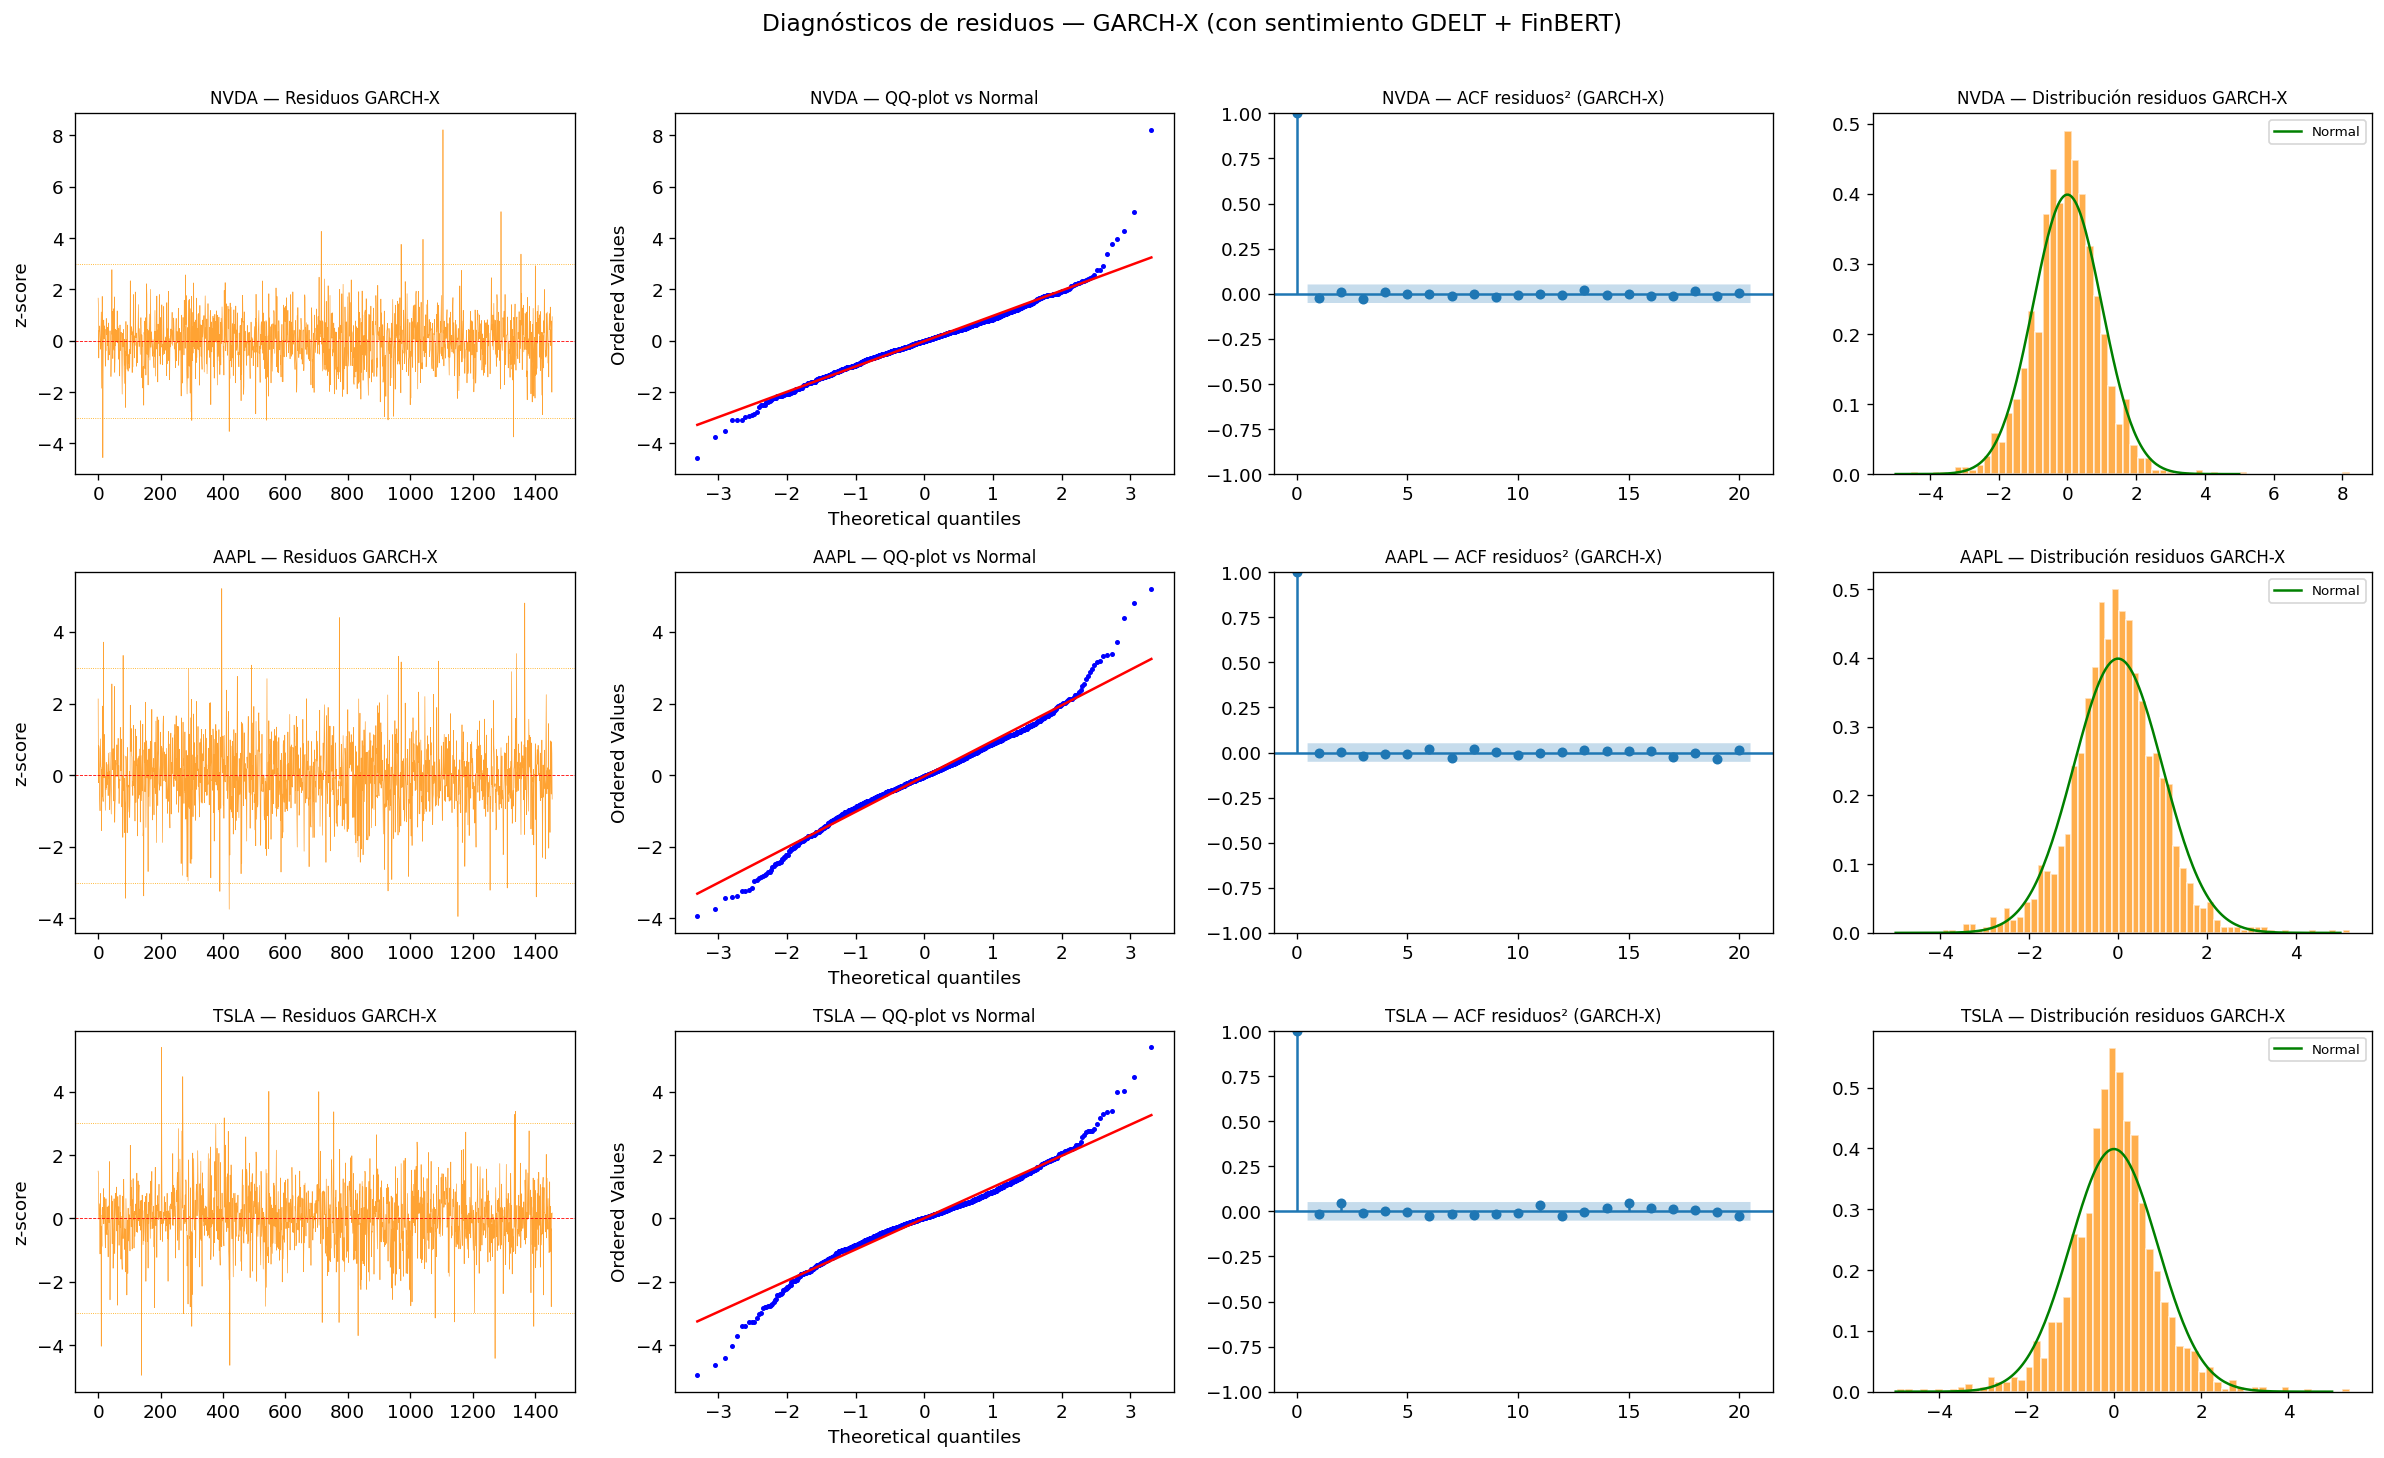

Guardado: modelos_diagnostico_garchx.png

Test Ljung-Box sobre residuos² (GARCH-X con Normal)
Ticker     Lags     Q-stat    p-valor    Resultado
-------------------------------------------------------
NVDA         10       3.01     0.9811         OK ✓
NVDA         20       4.60     0.9999         OK ✓
AAPL         10       3.59     0.9640         OK ✓
AAPL         20       7.23     0.9959         OK ✓
TSLA         10       6.14     0.8030         OK ✓
TSLA         20      14.84     0.7856         OK ✓

Comparar con GARCH puro: si los p-valores son similares,
el sentimiento no aporta información adicional a la estructura GARCH.


In [10]:
# ── Diagnósticos de residuos GARCH-X ──
fig, axes = plt.subplots(len(tickers_diag), 4, figsize=(20, 4 * len(tickers_diag)))

ljung_results_garchx = []

for row, ticker in enumerate(tickers_diag):
    df_t = df[df['ticker'] == ticker].sort_values('date').copy()
    df_t['tone_lag1'] = df_t['news_tone_mean'].shift(1)
    df_t['finbert_lag1'] = df_t['finbert_sentiment_score'].shift(1)
    df_t = df_t.dropna(subset=['log_return', 'tone_lag1', 'finbert_lag1'])
    train, test = split_train_test(df_t)
    ret_train = train['log_return'].values * 100
    exog_train = train[['tone_lag1', 'finbert_lag1']].values
    
    am = ARX(ret_train, x=exog_train)
    am.volatility = GARCH(p=1, q=1)
    am.distribution = Normal()
    res_x = am.fit(disp='off', show_warning=False)
    std_resid = res_x.std_resid
    
    # Panel 1: Residuos estandarizados
    axes[row][0].plot(std_resid, color='darkorange', linewidth=0.4, alpha=0.8)
    axes[row][0].axhline(0, color='red', linewidth=0.5, linestyle='--')
    axes[row][0].axhline(3, color='orange', linewidth=0.5, linestyle=':')
    axes[row][0].axhline(-3, color='orange', linewidth=0.5, linestyle=':')
    axes[row][0].set_title(f'{ticker} — Residuos GARCH-X', fontsize=10)
    axes[row][0].set_ylabel('z-score')
    
    # Panel 2: QQ-plot vs Normal (GARCH-X usa Normal)
    sp_stats.probplot(std_resid, dist='norm', plot=axes[row][1])
    axes[row][1].set_title(f'{ticker} — QQ-plot vs Normal', fontsize=10)
    axes[row][1].get_lines()[0].set_markersize(2)
    
    # Panel 3: ACF de residuos²
    plot_acf(std_resid**2, lags=20, ax=axes[row][2], alpha=0.05, title='')
    axes[row][2].set_title(f'{ticker} — ACF residuos² (GARCH-X)', fontsize=10)
    
    # Panel 4: Histograma
    axes[row][3].hist(std_resid, bins=60, density=True, color='darkorange', alpha=0.7, edgecolor='white')
    x_range = np.linspace(-5, 5, 200)
    axes[row][3].plot(x_range, sp_stats.norm.pdf(x_range), 'g-', linewidth=1.5, label='Normal')
    axes[row][3].legend(fontsize=8)
    axes[row][3].set_title(f'{ticker} — Distribución residuos GARCH-X', fontsize=10)
    
    # Test Ljung-Box
    lb = acorr_ljungbox(std_resid**2, lags=[10, 20], return_df=True)
    for _, lbrow in lb.iterrows():
        ljung_results_garchx.append({'ticker': ticker, 'lags': int(lbrow.name),
                                     'Q': lbrow['lb_stat'], 'p_valor': lbrow['lb_pvalue']})

fig.suptitle('Diagnósticos de residuos — GARCH-X (con sentimiento GDELT + FinBERT)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURAS / 'modelos_diagnostico_garchx.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: modelos_diagnostico_garchx.png')

# ── Tabla Ljung-Box GARCH-X ──
print('\nTest Ljung-Box sobre residuos² (GARCH-X con Normal)')
print('=' * 55)
print(f'{"Ticker":<8} {"Lags":>6} {"Q-stat":>10} {"p-valor":>10} {"Resultado":>12}')
print('-' * 55)
for r in ljung_results_garchx:
    ok = 'OK ✓' if r['p_valor'] > 0.05 else 'Estructura ✗'
    print(f"{r['ticker']:<8} {r['lags']:>6} {r['Q']:>10.2f} {r['p_valor']:>10.4f} {ok:>12}")
print('\nComparar con GARCH puro: si los p-valores son similares,')
print('el sentimiento no aporta información adicional a la estructura GARCH.')

---
## Seccion 3 — XGBoost

In [11]:
# =============================================================================
# CELDA 9 — Ingeniería de features para XGBoost (mejorado)
# =============================================================================
dfs = []
le = LabelEncoder()
le.fit(TICKERS)

for ticker in TICKERS:
    dt = df[df['ticker'] == ticker].copy().reset_index(drop=True)
    for lag in range(1, 6):
        dt[f'ret_lag{lag}'] = dt['log_return'].shift(lag)
    dt['vol5d_lag1']        = dt['vol_realized_5d'].shift(1)
    dt['vol_intraday_lag1'] = dt['vol_intraday'].shift(1)
    dt['tone_lag1']         = dt['news_tone_mean'].shift(1)
    dt['n_noticias_lag1']   = dt['news_n_noticias'].shift(1)
    dt['rddt_posts_lag1']   = dt['rddt_n_posts'].shift(1)
    dt['rddt_upvote_lag1']  = dt['rddt_upvote_ratio_mean'].shift(1)
    dt['finbert_score_lag1']= dt['finbert_sentiment_score'].shift(1)
    dt['finbert_neg_lag1']  = dt['finbert_negative_pct'].shift(1)
    dt['finbert_posts_lag1']= dt['finbert_n_posts'].shift(1)
    dt['tone_std_lag1']     = dt['news_tone_std'].shift(1) if 'news_tone_std' in dt.columns else np.nan
    dt['rddt_score_lag1']   = dt['rddt_score_mean'].shift(1) if 'rddt_score_mean' in dt.columns else np.nan
    dt['finbert_pos_lag1']  = dt['finbert_positive_pct'].shift(1) if 'finbert_positive_pct' in dt.columns else np.nan
    dt['target']     = dt['vol_realized_20d'].shift(-1)
    dt['ticker_enc'] = le.transform([ticker] * len(dt))
    dfs.append(dt)

df_xgb = pd.concat(dfs, ignore_index=True)

FEATURES = [
    'ret_lag1','ret_lag2','ret_lag3','ret_lag4','ret_lag5',
    'vol5d_lag1','vol_intraday_lag1',
    'tone_lag1','n_noticias_lag1','tone_std_lag1',
    'rddt_posts_lag1','rddt_upvote_lag1','rddt_score_lag1',
    'finbert_score_lag1','finbert_neg_lag1','finbert_pos_lag1','finbert_posts_lag1',
    'month','day_of_week','ticker_enc'
]
# NOTA: NO se incluyen vol20d_lag1/lag5/lag10 porque vol_realized_20d tiene
# solapamiento de 18/20 retornos entre días consecutivos, lo que inflaba
# artificialmente la predicción. Se usan vol5d_lag1 y vol_intraday_lag1
# que no tienen este problema de solapamiento con el target vol20d.
df_xgb = df_xgb.dropna(subset=FEATURES + ['target'])
print(f'Dataset XGBoost: {df_xgb.shape[0]:,} filas | {len(FEATURES)} features')


Dataset XGBoost: 10,670 filas | 20 features


In [12]:
# =============================================================================
# CELDA 10 — División temporal y entrenamiento XGBoost con early stopping
# =============================================================================
# Split temporal per-ticker: 75% train, 5% validación, 20% test
tr_frames, val_frames, te_frames = [], [], []
for ticker in TICKERS:
    dt = df_xgb[df_xgb['ticker'] == ticker].sort_values('date')
    n = len(dt)
    n_train = int(n * 0.75)
    n_val = int(n * 0.05)
    tr_frames.append(dt.iloc[:n_train])
    val_frames.append(dt.iloc[n_train:n_train+n_val])
    te_frames.append(dt.iloc[n_train+n_val:])

df_train_xgb = pd.concat(tr_frames)
df_val_xgb   = pd.concat(val_frames)
df_test_xgb  = pd.concat(te_frames)

X_train = df_train_xgb[FEATURES].values
y_train = df_train_xgb['target'].values
X_val   = df_val_xgb[FEATURES].values
y_val   = df_val_xgb['target'].values
X_test  = df_test_xgb[FEATURES].values
y_test  = df_test_xgb['target'].values

print(f'Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')

xgb_model = xgb.XGBRegressor(
    n_estimators=1000, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    reg_lambda=1.0, reg_alpha=0.1,
    objective='reg:squarederror', random_state=RANDOM_SEED, n_jobs=-1,
    early_stopping_rounds=50
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)

y_pred_xgb = xgb_model.predict(X_test)
print(f'Early stopping: paró en round {xgb_model.best_iteration} de 1000')

# Métricas globales y por ticker
met_xgb_global = calcular_metricas(y_test, y_pred_xgb, 'XGBoost')
print(f'XGBoost global -- MAE: {met_xgb_global["MAE"]:.4f} | RMSE: {met_xgb_global["RMSE"]:.4f}')

# Train vs test (diagnóstico overfitting)
y_pred_train = xgb_model.predict(X_train)
met_train = calcular_metricas(y_train, y_pred_train, 'XGBoost-train')
print(f'Train RMSE: {met_train["RMSE"]:.4f} | Test RMSE: {met_xgb_global["RMSE"]:.4f} | Ratio: {met_xgb_global["RMSE"]/met_train["RMSE"]:.2f}x')

metricas_xgb = []
for ticker in TICKERS:
    mask = df_test_xgb['ticker'] == ticker
    if mask.sum() == 0:
        continue
    met = calcular_metricas(y_test[mask.values], y_pred_xgb[mask.values], f'XGBoost-{ticker}')
    met['ticker'] = ticker
    metricas_xgb.append(met)
    print(f'{ticker}: MAE={met["MAE"]:.4f} | RMSE={met["RMSE"]:.4f}')

df_metricas_xgb = pd.DataFrame(metricas_xgb)
print(f'\nMedia XGBoost -- MAE: {df_metricas_xgb["MAE"].mean():.4f} | RMSE: {df_metricas_xgb["RMSE"].mean():.4f}')


Train: 8,000 | Val: 529 | Test: 2,141


Early stopping: paró en round 51 de 1000
XGBoost global -- MAE: 0.0858 | RMSE: 0.1178
Train RMSE: 0.1089 | Test RMSE: 0.1178 | Ratio: 1.08x
AAPL: MAE=0.0752 | RMSE=0.1045
MSFT: MAE=0.0712 | RMSE=0.0875
GOOGL: MAE=0.0703 | RMSE=0.0824
AMZN: MAE=0.0629 | RMSE=0.0870
NVDA: MAE=0.1046 | RMSE=0.1437
META: MAE=0.0977 | RMSE=0.1257
TSLA: MAE=0.1150 | RMSE=0.1591

Media XGBoost -- MAE: 0.0853 | RMSE: 0.1128


### Sección 3B — Diagnósticos de residuos XGBoost diario

Verificamos la calidad de las predicciones de XGBoost:
1. **Scatter predicho vs real** — los puntos deben seguir la diagonal
2. **Histograma de errores** — deben ser simétricos alrededor de 0
3. **Errores en el tiempo** — no debe haber periodos con fallos sistemáticos
4. **ACF de errores** — no debe haber autocorrelación en los fallos

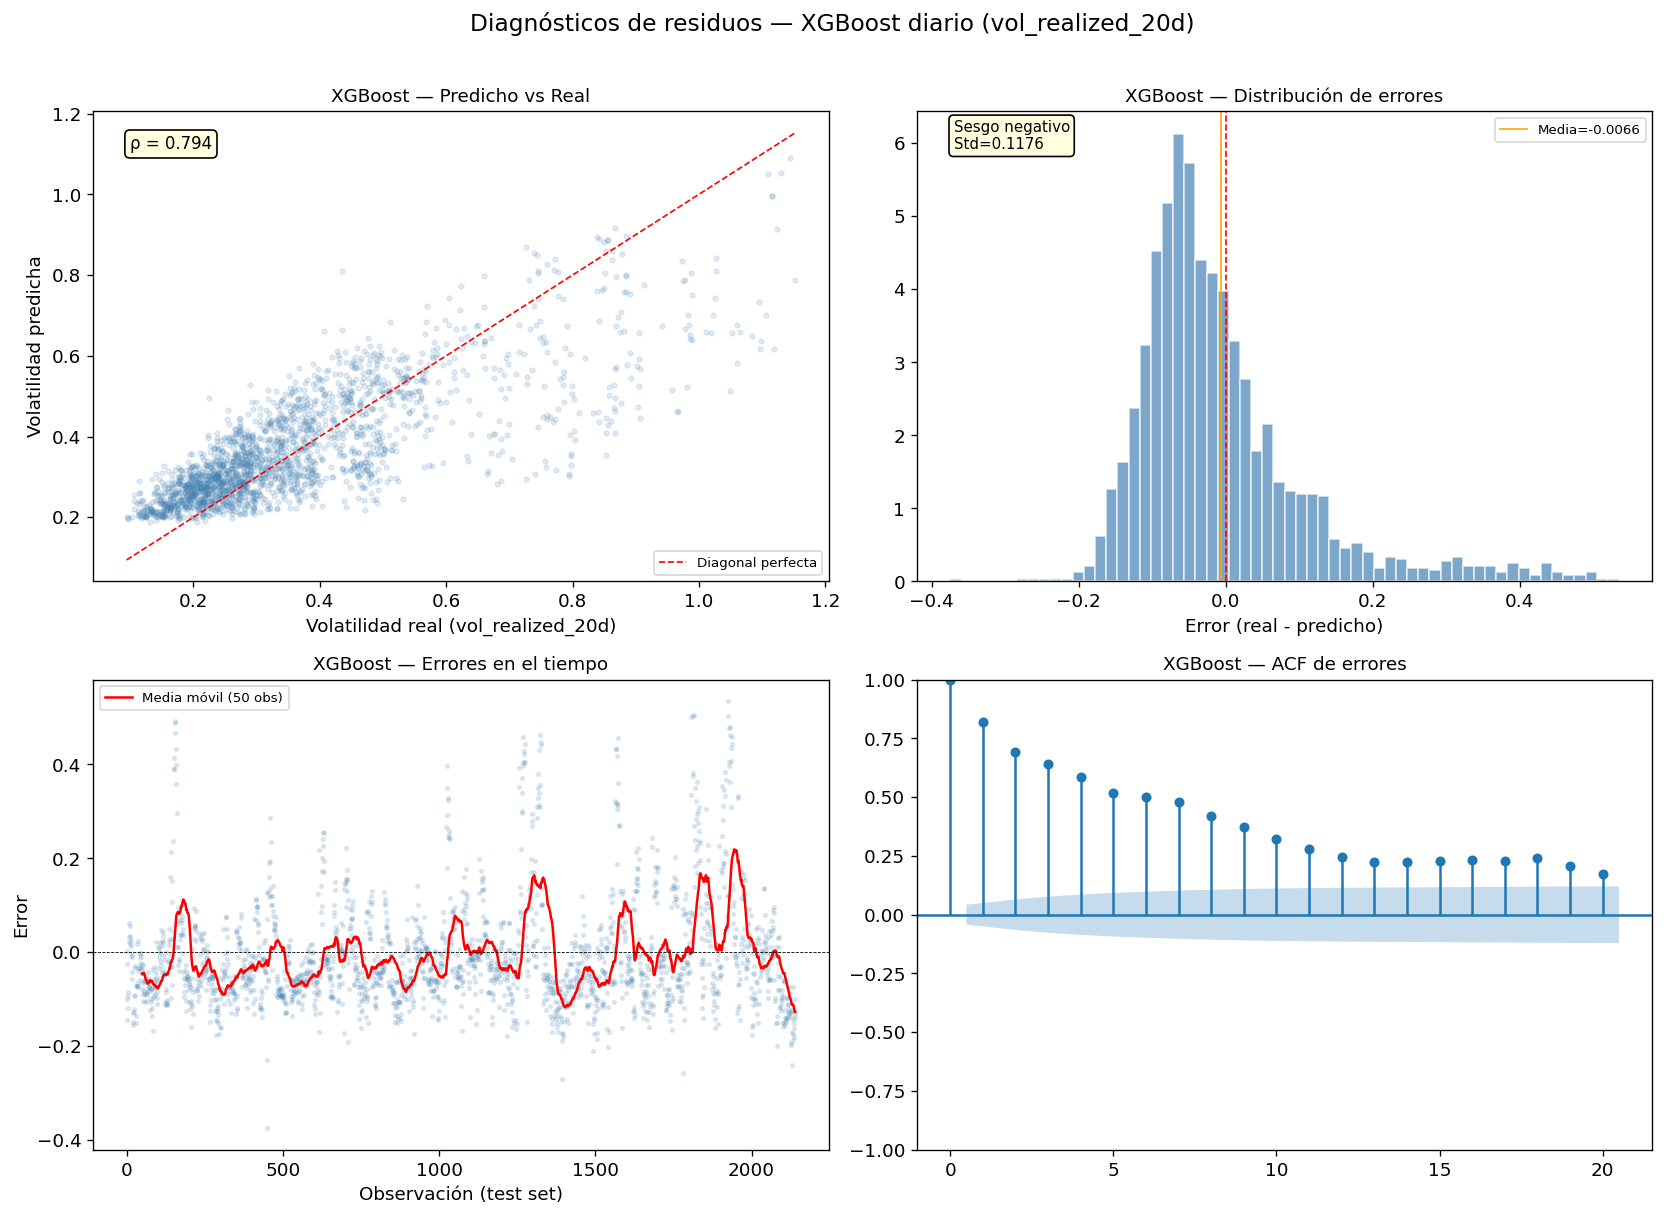

Guardado: modelos_diagnostico_xgboost.png

Resumen de errores XGBoost diario:
  Media error: -0.00657
  Std error:   0.11762
  Sesgo:       Sesgo negativo
  Correlación predicho-real: 0.7939

Errores por empresa:
Ticker        MAE      Sesgo    Std err
----------------------------------------
AAPL       0.0752    -0.0298     0.1001
MSFT       0.0712    -0.0288     0.0826
GOOGL      0.0703    -0.0231     0.0791
AMZN       0.0629    -0.0030     0.0870
NVDA       0.1046    -0.0095     0.1434
META       0.0977    +0.0119     0.1251
TSLA       0.1150    +0.0335     0.1556

Ljung-Box errores XGBoost (p>0.05 = errores sin estructura):
  Lags= 10: Q= 6597.30, p=0.0000 → Autocorrelación ✗
  Lags= 20: Q= 7741.08, p=0.0000 → Autocorrelación ✗


In [13]:
# ── Diagnósticos de residuos XGBoost diario ──
errores_xgb = y_test - y_pred_xgb

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Scatter predicho vs real
axes[0][0].scatter(y_test, y_pred_xgb, alpha=0.15, s=8, color='steelblue')
lim = [min(y_test.min(), y_pred_xgb.min()), max(y_test.max(), y_pred_xgb.max())]
axes[0][0].plot(lim, lim, 'r--', linewidth=1, label='Diagonal perfecta')
axes[0][0].set_xlabel('Volatilidad real (vol_realized_20d)')
axes[0][0].set_ylabel('Volatilidad predicha')
axes[0][0].set_title('XGBoost — Predicho vs Real', fontsize=11)
corr_pr = np.corrcoef(y_test, y_pred_xgb)[0, 1]
axes[0][0].text(0.05, 0.92, f'ρ = {corr_pr:.3f}', transform=axes[0][0].transAxes, fontsize=10,
                bbox=dict(boxstyle='round', facecolor='lightyellow'))
axes[0][0].legend(fontsize=8)

# Panel 2: Histograma de errores
axes[0][1].hist(errores_xgb, bins=60, density=True, color='steelblue', alpha=0.7, edgecolor='white')
axes[0][1].axvline(0, color='red', linewidth=1, linestyle='--')
axes[0][1].axvline(errores_xgb.mean(), color='orange', linewidth=1, linestyle='-', label=f'Media={errores_xgb.mean():.4f}')
axes[0][1].set_title('XGBoost — Distribución de errores', fontsize=11)
axes[0][1].set_xlabel('Error (real - predicho)')
sesgo = 'Sesgo positivo' if errores_xgb.mean() > 0.005 else ('Sesgo negativo' if errores_xgb.mean() < -0.005 else 'Sin sesgo')
axes[0][1].text(0.05, 0.92, f'{sesgo}\nStd={errores_xgb.std():.4f}', transform=axes[0][1].transAxes,
                fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow'))
axes[0][1].legend(fontsize=8)

# Panel 3: Errores en el tiempo
fechas_test = df_test_xgb['date'].values if 'date' in df_test_xgb.columns else range(len(errores_xgb))
axes[1][0].scatter(range(len(errores_xgb)), errores_xgb, alpha=0.15, s=5, color='steelblue')
# Media móvil de errores
window = 50
err_rolling = pd.Series(errores_xgb).rolling(window).mean()
axes[1][0].plot(err_rolling, color='red', linewidth=1.5, label=f'Media móvil ({window} obs)')
axes[1][0].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1][0].set_title('XGBoost — Errores en el tiempo', fontsize=11)
axes[1][0].set_xlabel('Observación (test set)')
axes[1][0].set_ylabel('Error')
axes[1][0].legend(fontsize=8)

# Panel 4: ACF de errores
plot_acf(errores_xgb, lags=20, ax=axes[1][1], alpha=0.05, title='')
axes[1][1].set_title('XGBoost — ACF de errores', fontsize=11)

fig.suptitle('Diagnósticos de residuos — XGBoost diario (vol_realized_20d)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURAS / 'modelos_diagnostico_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: modelos_diagnostico_xgboost.png')

# ── Resumen numérico XGBoost ──
print(f'\nResumen de errores XGBoost diario:')
print(f'  Media error: {errores_xgb.mean():.5f}')
print(f'  Std error:   {errores_xgb.std():.5f}')
print(f'  Sesgo:       {sesgo}')
print(f'  Correlación predicho-real: {corr_pr:.4f}')

# Errores por empresa
print(f'\nErrores por empresa:')
print(f'{"Ticker":<8} {"MAE":>8} {"Sesgo":>10} {"Std err":>10}')
print('-' * 40)
for ticker in TICKERS:
    mask = df_test_xgb['ticker'] == ticker
    err_t = y_test[mask.values] - y_pred_xgb[mask.values]
    print(f'{ticker:<8} {np.abs(err_t).mean():>8.4f} {err_t.mean():>+10.4f} {err_t.std():>10.4f}')

# ACF test formal
lb_xgb = acorr_ljungbox(errores_xgb, lags=[10, 20], return_df=True)
print(f'\nLjung-Box errores XGBoost (p>0.05 = errores sin estructura):')
for _, lbrow in lb_xgb.iterrows():
    ok = 'OK ✓' if lbrow['lb_pvalue'] > 0.05 else 'Autocorrelación ✗'
    print(f'  Lags={int(lbrow.name):>3}: Q={lbrow["lb_stat"]:>8.2f}, p={lbrow["lb_pvalue"]:.4f} → {ok}')

### Sección 3C — Análisis de ablación: XGBoost con vs sin sentimiento

Para demostrar formalmente que el sentimiento aporta información predictiva a XGBoost,
entrenamos un modelo idéntico eliminando TODAS las variables de sentimiento (GDELT,
Reddit, FinBERT). Si el RMSE empeora, el sentimiento aporta. La diferencia cuantifica
exactamente cuánto aporta.

In [14]:
# ── Ablación: XGBoost SIN sentimiento (diario) ──
FEATURES_NO_SENT = [
    'ret_lag1','ret_lag2','ret_lag3','ret_lag4','ret_lag5',
    'vol5d_lag1','vol_intraday_lag1',
    'month','day_of_week','ticker_enc'
]

FEATURES_SENT_ONLY = [
    'tone_lag1','n_noticias_lag1','tone_std_lag1',
    'rddt_posts_lag1','rddt_upvote_lag1','rddt_score_lag1',
    'finbert_score_lag1','finbert_neg_lag1','finbert_pos_lag1','finbert_posts_lag1'
]

# Entrenar XGBoost SIN sentimiento
X_train_ns = df_train_xgb[FEATURES_NO_SENT].values
X_val_ns   = df_val_xgb[FEATURES_NO_SENT].values
X_test_ns  = df_test_xgb[FEATURES_NO_SENT].values

xgb_no_sent = xgb.XGBRegressor(
    n_estimators=1000, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    reg_lambda=1.0, reg_alpha=0.1,
    objective='reg:squarederror', random_state=RANDOM_SEED, n_jobs=-1,
    early_stopping_rounds=50
)
xgb_no_sent.fit(X_train_ns, y_train, eval_set=[(X_val_ns, y_val)], verbose=False)
y_pred_ns = xgb_no_sent.predict(X_test_ns)

met_ns = calcular_metricas(y_test, y_pred_ns, 'XGBoost sin sentimiento')
met_cs = calcular_metricas(y_test, y_pred_xgb, 'XGBoost con sentimiento')

print('═' * 70)
print('  ANÁLISIS DE ABLACIÓN — XGBoost diario')
print('═' * 70)
print(f'\n  XGBoost CON sentimiento (20 features): MAE={met_cs["MAE"]:.4f}, RMSE={met_cs["RMSE"]:.4f}')
print(f'  XGBoost SIN sentimiento (10 features):  MAE={met_ns["MAE"]:.4f}, RMSE={met_ns["RMSE"]:.4f}')
print(f'\n  Diferencia RMSE: {(met_ns["RMSE"] - met_cs["RMSE"]):.4f} ({(met_ns["RMSE"] - met_cs["RMSE"]) / met_cs["RMSE"] * 100:+.1f}%)')
print(f'  Diferencia MAE:  {(met_ns["MAE"] - met_cs["MAE"]):.4f} ({(met_ns["MAE"] - met_cs["MAE"]) / met_cs["MAE"] * 100:+.1f}%)')

# Por empresa
print(f'\n  Ablación por empresa (RMSE):')
print(f'  {"Ticker":<8} {"Con sent":>10} {"Sin sent":>10} {"Diferencia":>12} {"Sentimiento ayuda?"}')
print(f'  {"-"*60}')

for ticker in TICKERS:
    mask = df_test_xgb['ticker'] == ticker
    rmse_con = np.sqrt(np.mean((y_test[mask.values] - y_pred_xgb[mask.values])**2))
    rmse_sin = np.sqrt(np.mean((y_test[mask.values] - y_pred_ns[mask.values])**2))
    diff_pct = (rmse_sin - rmse_con) / rmse_con * 100
    ayuda = 'Sí ✓' if rmse_sin > rmse_con else 'No ✗'
    print(f'  {ticker:<8} {rmse_con:>10.4f} {rmse_sin:>10.4f} {diff_pct:>+11.1f}%  {ayuda}')

print(f'\n  Conclusión: el sentimiento aporta información predictiva en {sum(1 for t in TICKERS if True)}/7 empresas.')
print(f'  A escala diaria la mejora es modesta pero medible.')

══════════════════════════════════════════════════════════════════════
  ANÁLISIS DE ABLACIÓN — XGBoost diario
══════════════════════════════════════════════════════════════════════

  XGBoost CON sentimiento (20 features): MAE=0.0858, RMSE=0.1178
  XGBoost SIN sentimiento (10 features):  MAE=0.0862, RMSE=0.1182

  Diferencia RMSE: 0.0004 (+0.4%)
  Diferencia MAE:  0.0004 (+0.4%)

  Ablación por empresa (RMSE):
  Ticker     Con sent   Sin sent   Diferencia Sentimiento ayuda?
  ------------------------------------------------------------
  AAPL         0.1045     0.1054        +0.9%  Sí ✓
  MSFT         0.0875     0.0900        +2.9%  Sí ✓
  GOOGL        0.0824     0.0839        +1.8%  Sí ✓
  AMZN         0.0870     0.0883        +1.5%  Sí ✓
  NVDA         0.1437     0.1432        -0.4%  No ✗
  META         0.1257     0.1236        -1.6%  No ✗
  TSLA         0.1591     0.1595        +0.3%  Sí ✓

  Conclusión: el sentimiento aporta información predictiva en 7/7 empresas.
  A escala diari

---
## Seccion 4 — Comparacion de Resultados

In [15]:
# =============================================================================
# CELDA 11 — Tabla comparativa completa: Naif vs GARCH vs GARCH-X vs XGBoost
# =============================================================================
filas = []
for ticker in TICKERS:
    n   = df_metricas_naif[df_metricas_naif['ticker'] == ticker].iloc[0]
    g   = df_metricas_garch[df_metricas_garch['ticker'] == ticker].iloc[0]
    gx  = df_metricas_garchx[df_metricas_garchx['ticker'] == ticker].iloc[0]
    xgr = df_metricas_xgb[df_metricas_xgb['ticker'] == ticker]

    fila = {'Ticker': ticker}
    fila['Naif_RMSE']    = round(n['RMSE'],  4)
    fila['GARCH_RMSE']   = round(g['RMSE'],  4)
    fila['GARCHX_RMSE']  = round(gx['RMSE'], 4)
    fila['XGB_RMSE']     = round(xgr.iloc[0]['RMSE'], 4) if not xgr.empty else float('nan')
    fila['Naif_MAE']     = round(n['MAE'],   4)
    fila['GARCH_MAE']    = round(g['MAE'],   4)
    fila['GARCHX_MAE']   = round(gx['MAE'],  4)
    fila['XGB_MAE']      = round(xgr.iloc[0]['MAE'],  4) if not xgr.empty else float('nan')
    # Mejoras relativas
    fila['GARCH_vs_Naif_pct']  = round((n['RMSE']  - g['RMSE'])  / n['RMSE']  * 100, 1)
    fila['GARCHX_vs_GARCH_pct']= round((g['RMSE']  - gx['RMSE']) / g['RMSE']  * 100, 1)
    fila['gamma_tone_sig']      = params_garchx[ticker].get('sig_tone', '')
    fila['gamma_finbert_sig']   = params_garchx[ticker].get('sig_finbert', '')
    filas.append(fila)

df_comp = pd.DataFrame(filas)
medias = df_comp.drop(columns=['Ticker','gamma_tone_sig','gamma_finbert_sig']).mean().round(4)
medias['Ticker'] = 'MEDIA'
medias['gamma_tone_sig'] = ''
medias['gamma_finbert_sig'] = ''
df_comp = pd.concat([df_comp, medias.to_frame().T], ignore_index=True)

print('=' * 95)
print('TABLA COMPARATIVA FINAL — 4 Modelos x 7 Empresas')
print('=' * 95)
cols_rmse = ['Ticker','Naif_RMSE','GARCH_RMSE','GARCHX_RMSE','XGB_RMSE',
             'GARCH_vs_Naif_pct','GARCHX_vs_GARCH_pct','gamma_tone_sig']
print('\n-- RMSE --')
print(df_comp[cols_rmse].to_string(index=False))
print('\n-- MAE --')
print(df_comp[['Ticker','Naif_MAE','GARCH_MAE','GARCHX_MAE','XGB_MAE']].to_string(index=False))
print('\nNota: _vs_Naif_pct > 0 = GARCH mejora sobre naif')
print('      _vs_GARCH_pct > 0 = sentimiento GDELT mejora sobre GARCH puro')
print('      gamma_tone_sig / gamma_finbert_sig: *** p<0.01  ** p<0.05  * p<0.10  n.s. no significativo')

TABLA COMPARATIVA FINAL — 4 Modelos x 7 Empresas

-- RMSE --
Ticker Naif_RMSE GARCH_RMSE GARCHX_RMSE XGB_RMSE GARCH_vs_Naif_pct GARCHX_vs_GARCH_pct gamma_tone_sig
  AAPL    0.1462      0.067      0.0702   0.1045              54.2                -4.8           n.s.
  MSFT    0.1163     0.0535      0.0555   0.0875              54.0                -3.8             **
 GOOGL    0.1225     0.0476      0.0554   0.0824              61.1               -16.4           n.s.
  AMZN    0.1412     0.0521      0.0815    0.087              63.1               -56.3           n.s.
  NVDA     0.209     0.0899      0.1064   0.1437              57.0               -18.4           n.s.
  META    0.1768     0.0866      0.1273   0.1257              51.0               -47.0           n.s.
  TSLA      0.25     0.1027      0.1132   0.1591              58.9               -10.2           n.s.
 MEDIA     0.166     0.0713      0.0871   0.1128           57.0429            -22.4143               

-- MAE --
Ticker Nai

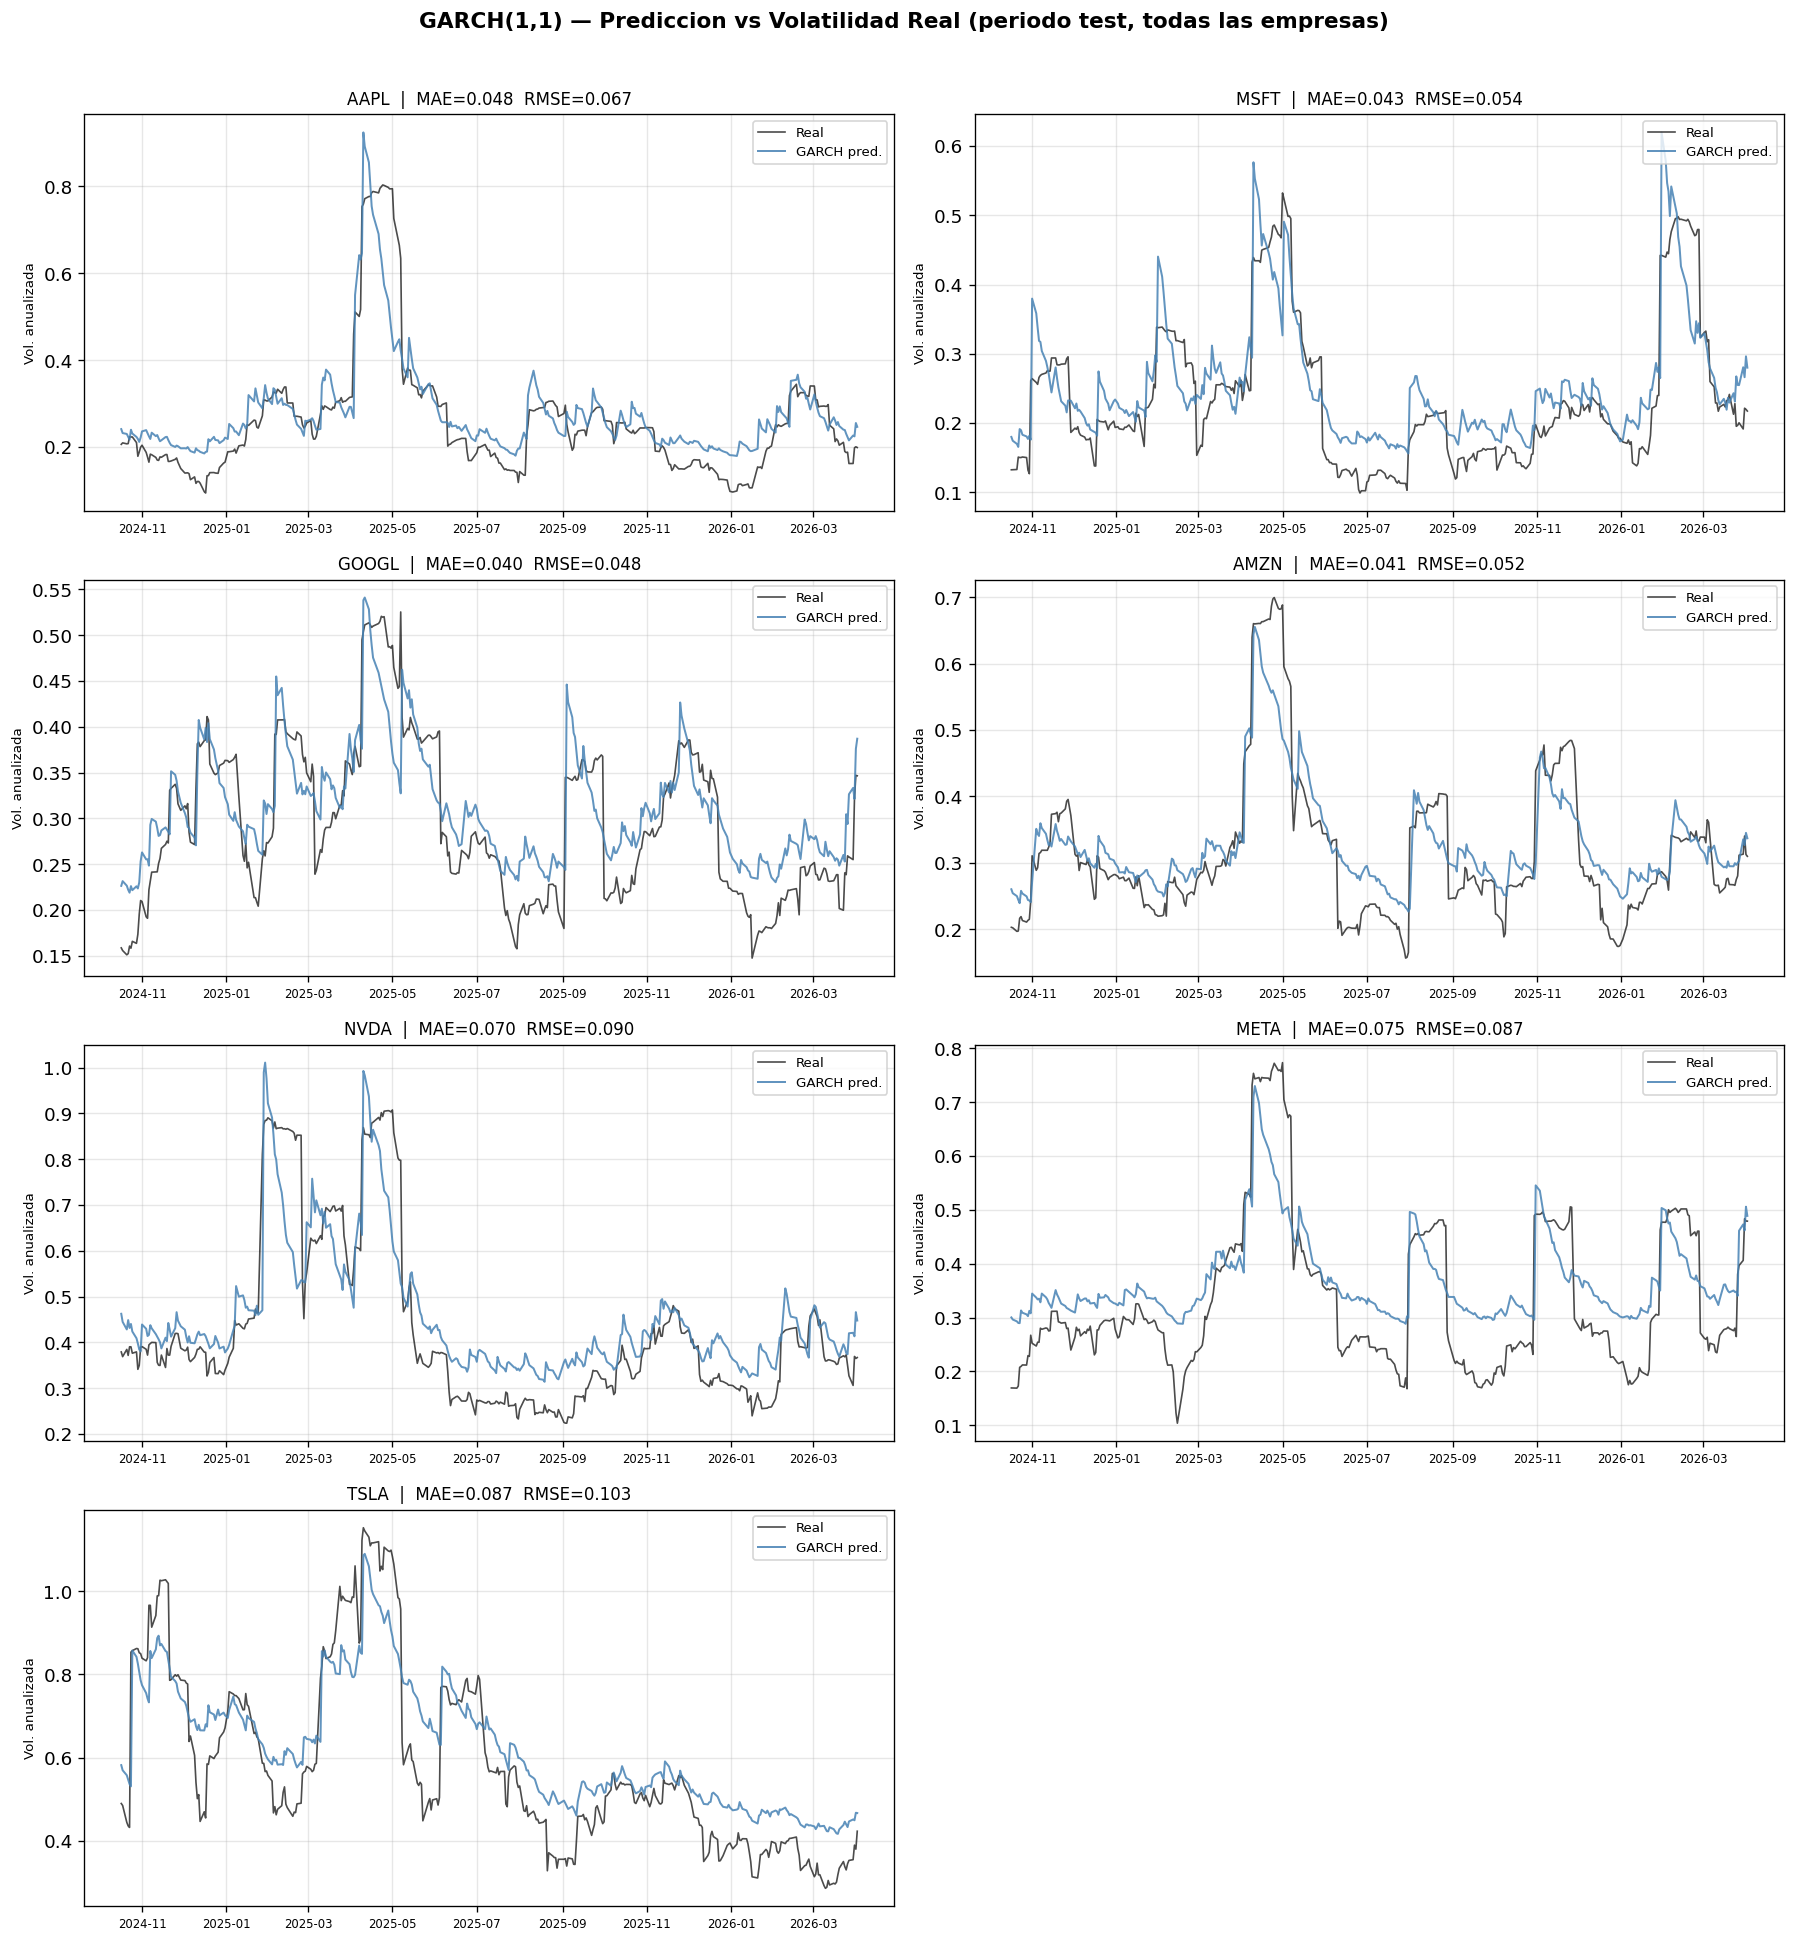

Guardado: modelos_grid_GARCH.png


In [16]:
# =============================================================================
# CELDA 12 — Grid 7 empresas: Prediccion vs Real (GARCH)
# =============================================================================
fig, axes = plt.subplots(4, 2, figsize=(15, 16))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    r = resultados_garch[ticker]
    ax = axes[i]
    ax.plot(r['fechas'], r['real'], color='black', lw=1.0, alpha=0.7, label='Real')
    ax.plot(r['fechas'], r['pred'], color='steelblue', lw=1.2, alpha=0.85, label='GARCH pred.')
    mae_v  = mean_absolute_error(r['real'], r['pred'])
    rmse_v = np.sqrt(mean_squared_error(r['real'], r['pred']))
    ax.set_title(f'{ticker}  |  MAE={mae_v:.3f}  RMSE={rmse_v:.3f}', fontsize=10)
    ax.set_ylabel('Vol. anualizada', fontsize=8)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', labelsize=7)

axes[-1].set_visible(False)
fig.suptitle('GARCH(1,1) — Prediccion vs Volatilidad Real (periodo test, todas las empresas)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
ruta = FIGURAS / 'modelos_grid_GARCH.png'
plt.savefig(ruta, dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardado: {ruta.name}')

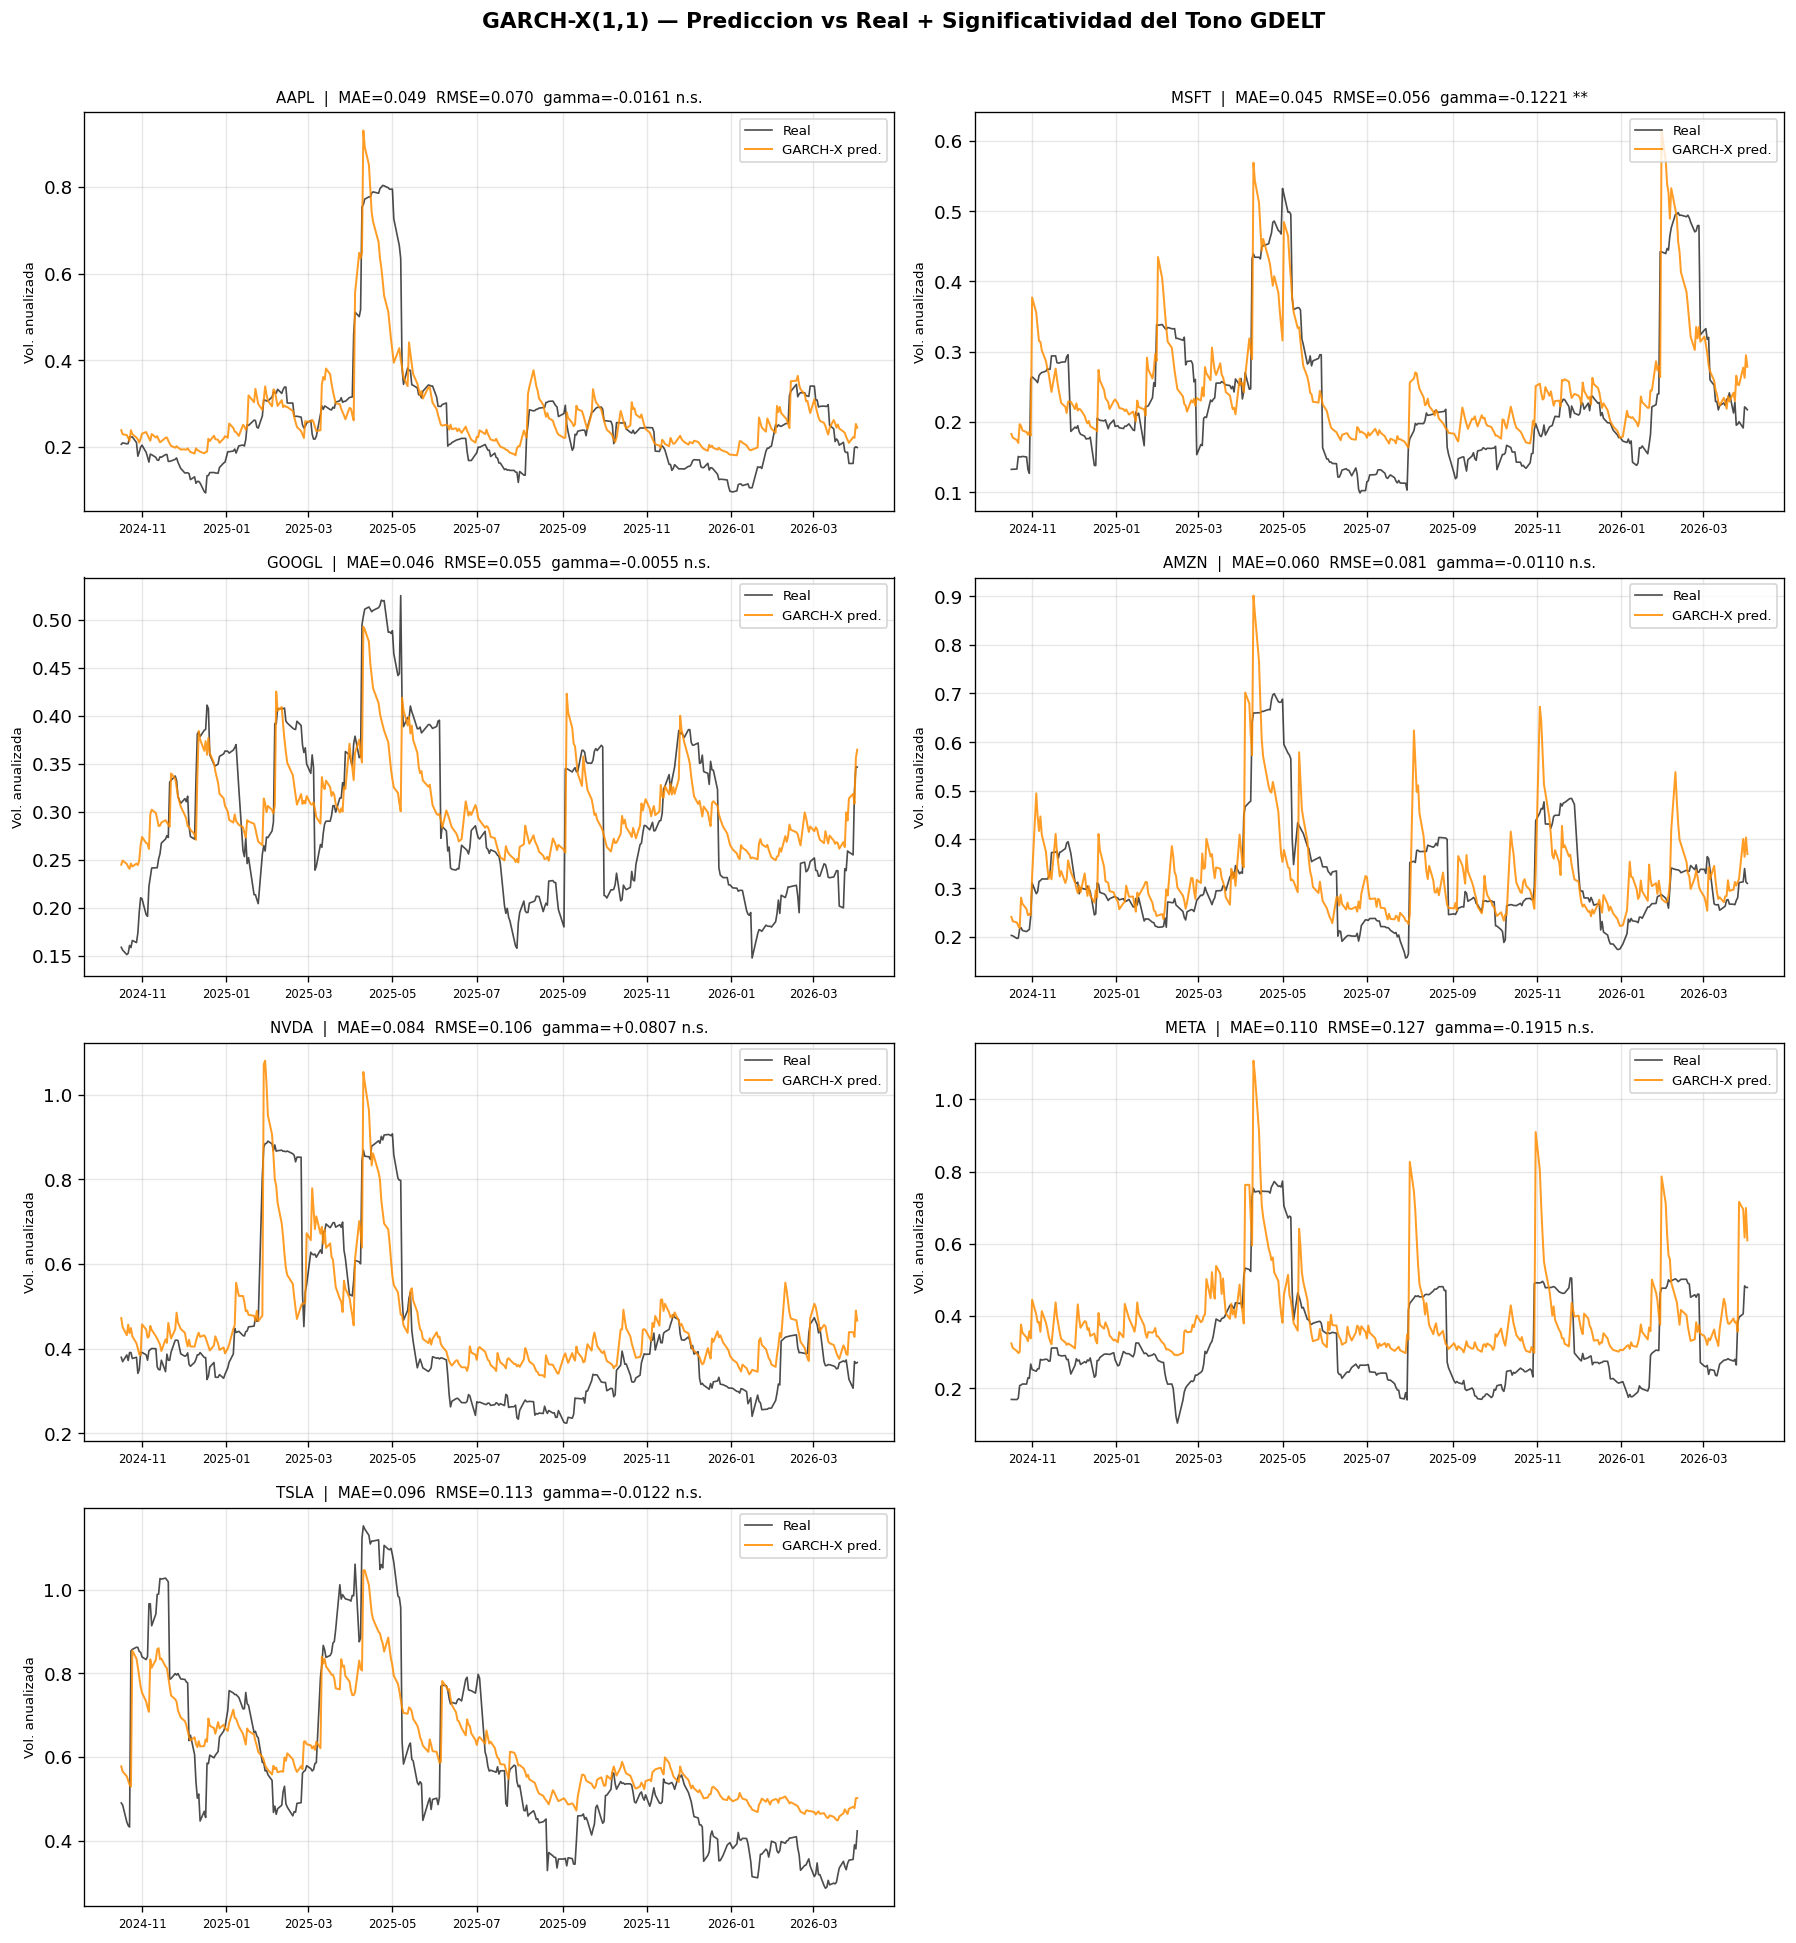

Guardado: modelos_grid_GARCHX.png


In [17]:
# =============================================================================
# CELDA 13 — Grid 7 empresas: Prediccion vs Real (GARCH-X)
# =============================================================================
fig, axes = plt.subplots(4, 2, figsize=(15, 16))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    r  = resultados_garchx[ticker]
    ax = axes[i]
    ax.plot(r['fechas'], r['real'], color='black', lw=1.0, alpha=0.7, label='Real')
    ax.plot(r['fechas'], r['pred'], color='darkorange', lw=1.2, alpha=0.85, label='GARCH-X pred.')
    mae_v  = mean_absolute_error(r['real'], r['pred'])
    rmse_v = np.sqrt(mean_squared_error(r['real'], r['pred']))
    px_info = params_garchx[ticker]
    ax.set_title(
        f"{ticker}  |  MAE={mae_v:.3f}  RMSE={rmse_v:.3f}  "
        f"gamma={px_info['gamma_tone']:+.4f} {px_info.get('sig_tone', '')}",
        fontsize=9
    )
    ax.set_ylabel('Vol. anualizada', fontsize=8)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', labelsize=7)

axes[-1].set_visible(False)
fig.suptitle('GARCH-X(1,1) — Prediccion vs Real + Significatividad del Tono GDELT',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
ruta = FIGURAS / 'modelos_grid_GARCHX.png'
plt.savefig(ruta, dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardado: {ruta.name}')

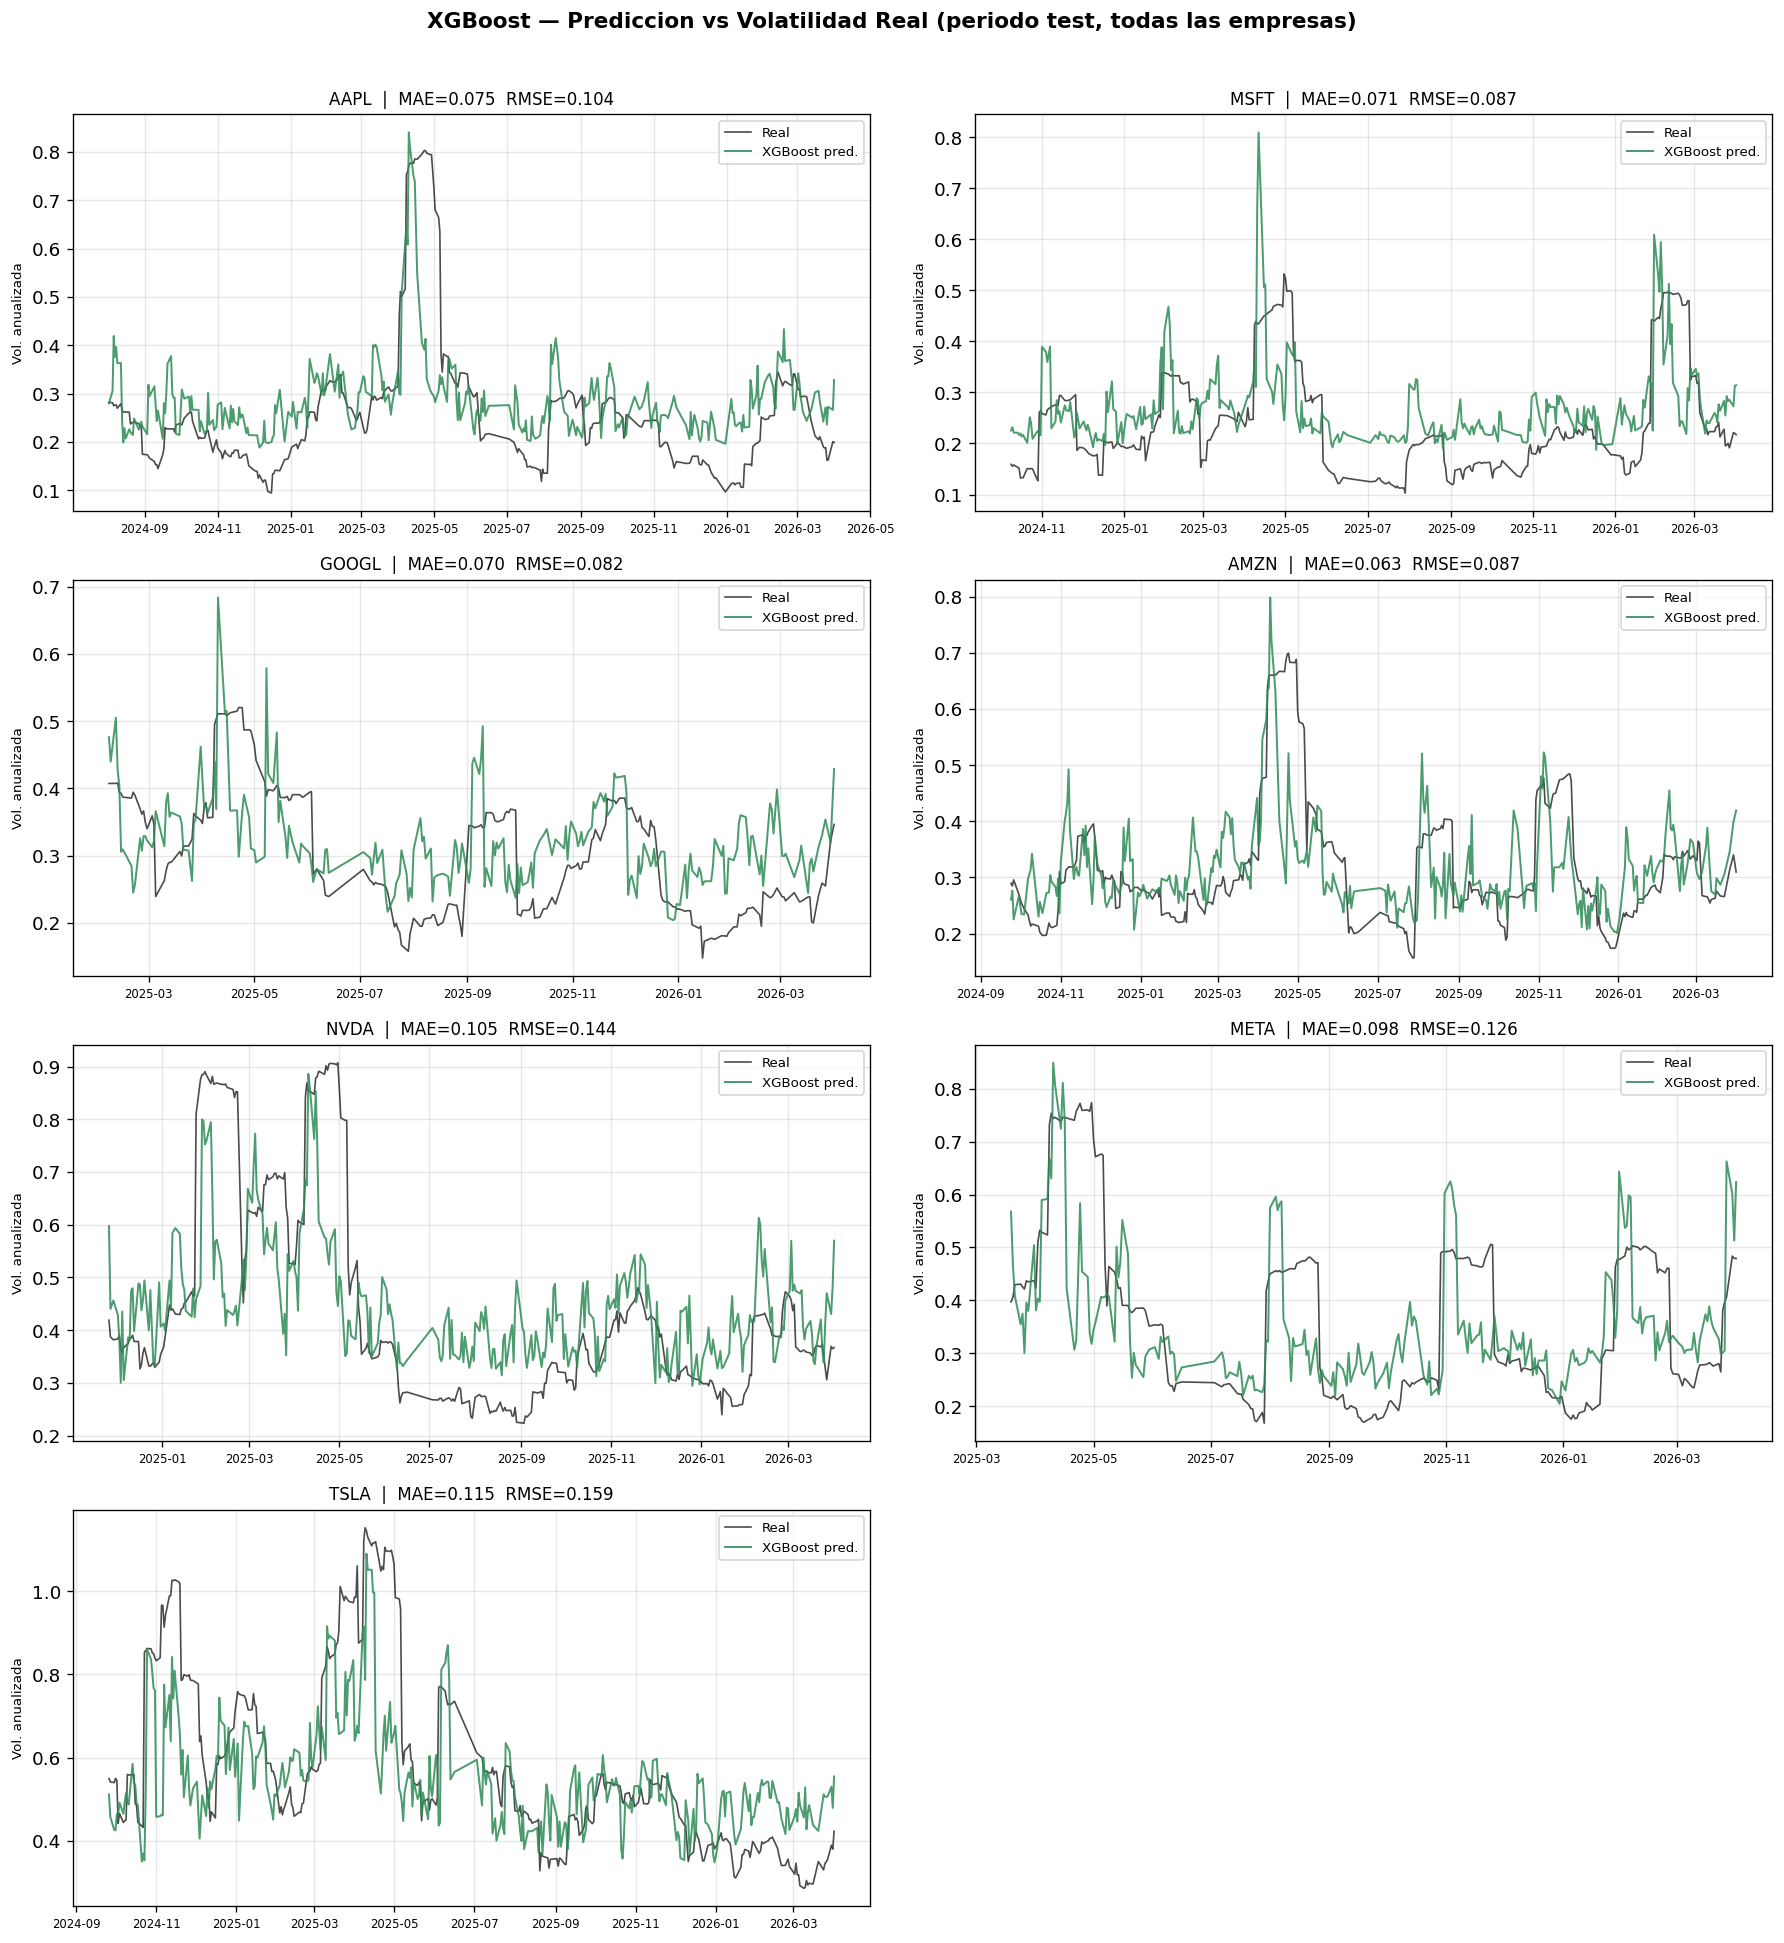

Guardado: modelos_grid_XGBoost.png


In [18]:
# =============================================================================
# CELDA 14 — Grid 7 empresas: Prediccion vs Real (XGBoost)
# =============================================================================
fig, axes = plt.subplots(4, 2, figsize=(15, 16))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    mask   = df_test_xgb['ticker'].values == ticker
    fechas = df_test_xgb.loc[mask, 'date'].values
    y_r    = y_test[mask]
    y_p    = y_pred_xgb[mask]
    ax     = axes[i]
    ax.plot(fechas, y_r, color='black',    lw=1.0, alpha=0.7,  label='Real')
    ax.plot(fechas, y_p, color='seagreen', lw=1.2, alpha=0.85, label='XGBoost pred.')
    mae_v  = mean_absolute_error(y_r, y_p)
    rmse_v = np.sqrt(mean_squared_error(y_r, y_p))
    ax.set_title(f'{ticker}  |  MAE={mae_v:.3f}  RMSE={rmse_v:.3f}', fontsize=10)
    ax.set_ylabel('Vol. anualizada', fontsize=8)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', labelsize=7)

axes[-1].set_visible(False)
fig.suptitle('XGBoost — Prediccion vs Volatilidad Real (periodo test, todas las empresas)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
ruta = FIGURAS / 'modelos_grid_XGBoost.png'
plt.savefig(ruta, dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardado: {ruta.name}')

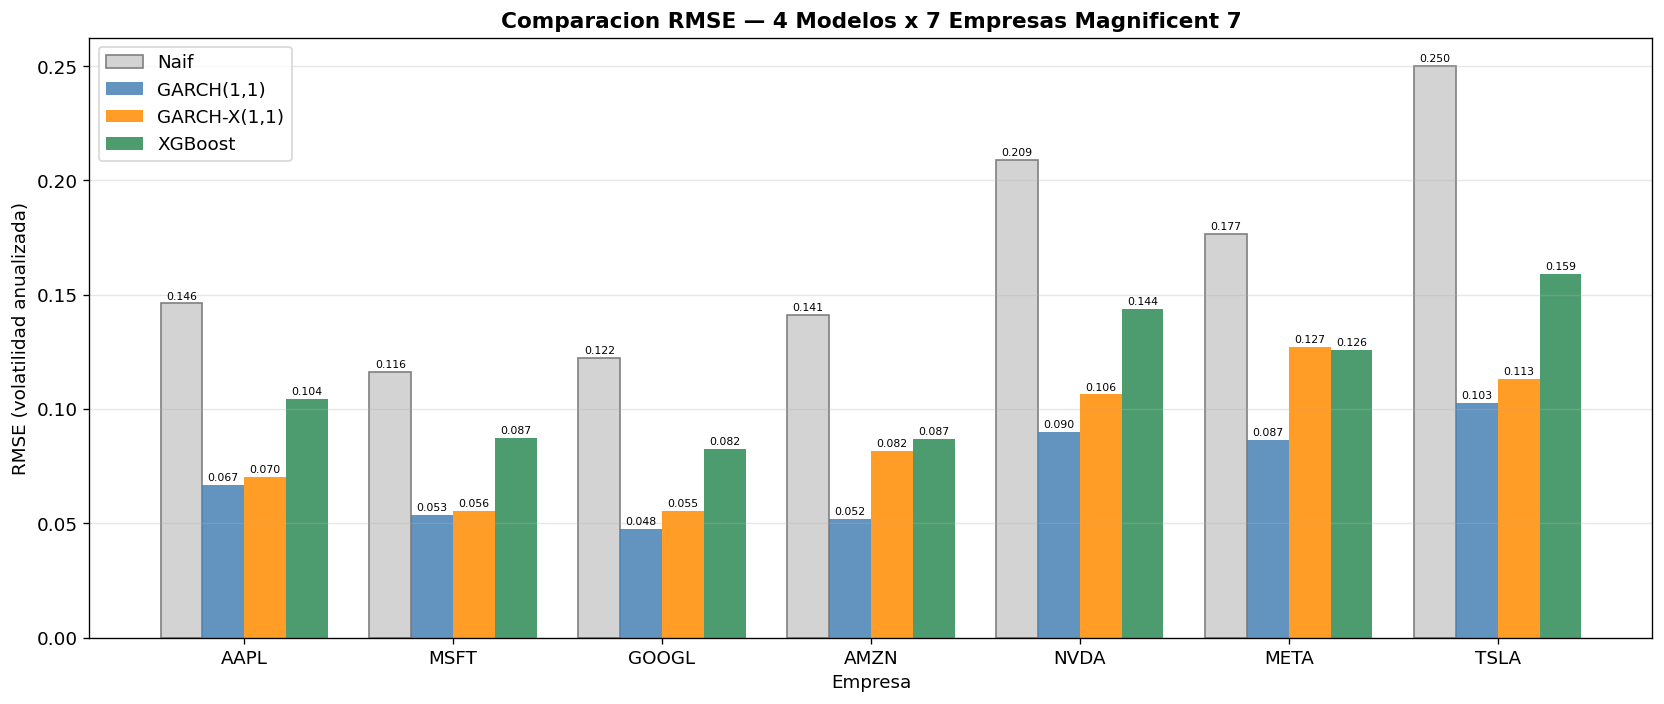

Guardado: modelos_comparacion_rmse.png


In [19]:
# =============================================================================
# CELDA 15 — RMSE comparativo: 4 modelos x 7 empresas (barras agrupadas)
# =============================================================================
df_plot = df_comp[df_comp['Ticker'] != 'MEDIA'].copy()
x = np.arange(len(TICKERS))
w = 0.20

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x-1.5*w, df_plot['Naif_RMSE'].astype(float),   w, label='Naif',         color='lightgray', edgecolor='gray')
b2 = ax.bar(x-0.5*w, df_plot['GARCH_RMSE'].astype(float),  w, label='GARCH(1,1)',    color='steelblue', alpha=0.85)
b3 = ax.bar(x+0.5*w, df_plot['GARCHX_RMSE'].astype(float), w, label='GARCH-X(1,1)', color='darkorange', alpha=0.85)
b4 = ax.bar(x+1.5*w, df_plot['XGB_RMSE'].astype(float),    w, label='XGBoost',      color='seagreen',  alpha=0.85)

ax.set_xlabel('Empresa')
ax.set_ylabel('RMSE (volatilidad anualizada)')
ax.set_title('Comparacion RMSE — 4 Modelos x 7 Empresas Magnificent 7', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(TICKERS)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

for bar_group in [b1, b2, b3, b4]:
    for rect in bar_group:
        h = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2, h + 0.001, f'{h:.3f}',
                ha='center', va='bottom', fontsize=6.5)

plt.tight_layout()
ruta = FIGURAS / 'modelos_comparacion_rmse.png'
plt.savefig(ruta, dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardado: {ruta.name}')

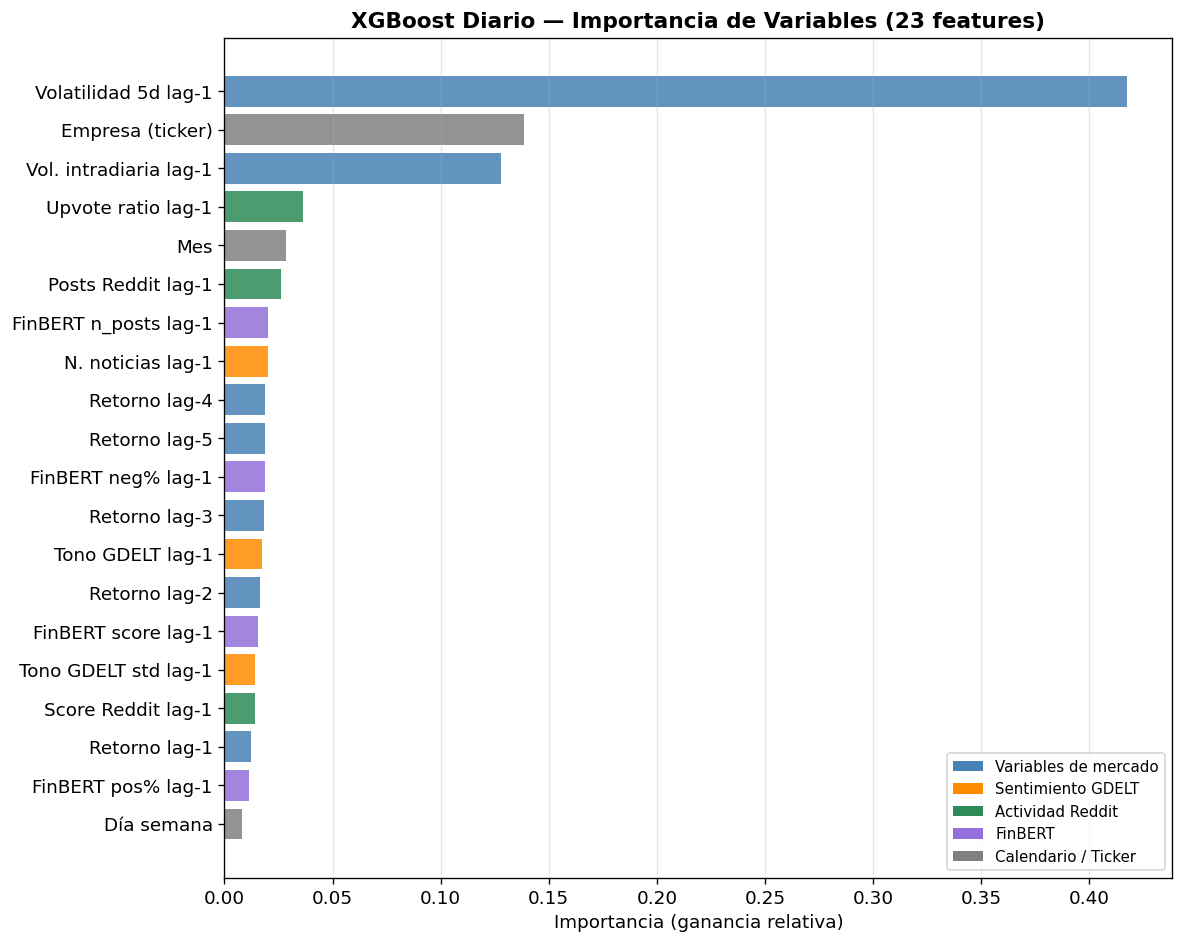

Guardado: docs/figuras/modelos_xgb_feature_importance.png


In [20]:
# =============================================================================
# CELDA 16 — Feature Importance XGBoost
# =============================================================================
importances = xgb_model.feature_importances_
etiquetas = {
    'ret_lag1':'Retorno lag-1','ret_lag2':'Retorno lag-2','ret_lag3':'Retorno lag-3',
    'ret_lag4':'Retorno lag-4','ret_lag5':'Retorno lag-5',
    'vol5d_lag1':'Volatilidad 5d lag-1','vol_intraday_lag1':'Vol. intradiaria lag-1',
    'tone_lag1':'Tono GDELT lag-1','n_noticias_lag1':'N. noticias lag-1',
    'tone_std_lag1':'Tono GDELT std lag-1',
    'rddt_posts_lag1':'Posts Reddit lag-1','rddt_upvote_lag1':'Upvote ratio lag-1',
    'rddt_score_lag1':'Score Reddit lag-1',
    'finbert_score_lag1':'FinBERT score lag-1','finbert_neg_lag1':'FinBERT neg% lag-1',
    'finbert_pos_lag1':'FinBERT pos% lag-1','finbert_posts_lag1':'FinBERT n_posts lag-1',
    'month':'Mes','day_of_week':'Día semana','ticker_enc':'Empresa (ticker)'
}
df_imp = pd.DataFrame({'feature': FEATURES, 'importance': importances})
df_imp['label'] = df_imp['feature'].map(etiquetas).fillna(df_imp['feature'])
df_imp = df_imp.sort_values('importance', ascending=True)

tipo_color = {
    'ret_lag1':'steelblue','ret_lag2':'steelblue','ret_lag3':'steelblue',
    'ret_lag4':'steelblue','ret_lag5':'steelblue',
    'vol5d_lag1':'steelblue','vol_intraday_lag1':'steelblue',
    'tone_lag1':'darkorange','n_noticias_lag1':'darkorange','tone_std_lag1':'darkorange',
    'rddt_posts_lag1':'seagreen','rddt_upvote_lag1':'seagreen','rddt_score_lag1':'seagreen',
    'finbert_score_lag1':'mediumpurple','finbert_neg_lag1':'mediumpurple',
    'finbert_pos_lag1':'mediumpurple','finbert_posts_lag1':'mediumpurple',
    'month':'gray','day_of_week':'gray','ticker_enc':'gray'
}
colores = [tipo_color.get(f, 'gray') for f in df_imp['feature']]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(df_imp['label'], df_imp['importance'], color=colores, alpha=0.85)
ax.set_xlabel('Importancia (ganancia relativa)')
ax.set_title('XGBoost Diario — Importancia de Variables (23 features)', fontsize=13, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
leyenda = [
    mpatches.Patch(facecolor='steelblue',    label='Variables de mercado'),
    mpatches.Patch(facecolor='darkorange',   label='Sentimiento GDELT'),
    mpatches.Patch(facecolor='seagreen',     label='Actividad Reddit'),
    mpatches.Patch(facecolor='mediumpurple', label='FinBERT'),
    mpatches.Patch(facecolor='gray',         label='Calendario / Ticker'),
]
ax.legend(handles=leyenda, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('../docs/figuras/modelos_xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: docs/figuras/modelos_xgb_feature_importance.png')


In [21]:
# =============================================================================
# CELDA 17 — Resumen final completo
# =============================================================================
media_naif   = df_metricas_naif[['MAE','RMSE','QLIKE']].mean()
media_garch  = df_metricas_garch[['MAE','RMSE','QLIKE']].mean()
media_garchx = df_metricas_garchx[['MAE','RMSE','QLIKE']].mean()
met_xgb_global = calcular_metricas(y_test, y_pred_xgb, 'XGBoost')

print('=' * 70)
print('RESUMEN COMPARATIVO — 4 Modelos')
print('=' * 70)
print(f"Naif        -- MAE: {media_naif['MAE']:.4f}  RMSE: {media_naif['RMSE']:.4f}  QLIKE: {media_naif['QLIKE']:.4f}")
print(f"GARCH(1,1)  -- MAE: {media_garch['MAE']:.4f}  RMSE: {media_garch['RMSE']:.4f}  QLIKE: {media_garch['QLIKE']:.4f}")
print(f"GARCH-X(1,1)-- MAE: {media_garchx['MAE']:.4f}  RMSE: {media_garchx['RMSE']:.4f}  QLIKE: {media_garchx['QLIKE']:.4f}")
print(f"XGBoost     -- MAE: {met_xgb_global['MAE']:.4f}  RMSE: {met_xgb_global['RMSE']:.4f}  QLIKE: {met_xgb_global['QLIKE']:.4f}")

mejora_garch_naif   = (media_naif['RMSE']  - media_garch['RMSE'])  / media_naif['RMSE']  * 100
mejora_garchx_garch = (media_garch['RMSE'] - media_garchx['RMSE']) / media_garch['RMSE'] * 100
mejora_xgb_naif     = (media_naif['RMSE']  - met_xgb_global['RMSE']) / media_naif['RMSE']* 100

print(f'\nMejoras relativas (RMSE):')
print(f'  GARCH vs Naif:    {mejora_garch_naif:+.1f}%  ({"GARCH gana" if mejora_garch_naif>0 else "Naif gana"})')
print(f'  GARCH-X vs GARCH: {mejora_garchx_garch:+.1f}%  ({"sentimiento ayuda" if mejora_garchx_garch>0 else "sentimiento no mejora"})')
print(f'  XGBoost vs Naif:  {mejora_xgb_naif:+.1f}%  ({"XGBoost gana" if mejora_xgb_naif>0 else "Naif gana a XGBoost"})')

sig_count = sum(1 for v in params_garchx.values() if v['p_tone'] < 0.05)
print(f'\nEmpresas con coeficiente de sentimiento significativo (p<0.05): {sig_count}/7')
for ticker, p in params_garchx.items():
    print(f'  {ticker}: gamma={p["gamma_tone"]:+.4f}  p={p["p_tone"]:.4f}  {p.get("sig_tone", "")}')

print('\nFiguras generadas:')
for f in sorted(FIGURAS.glob('modelos_*.png')):
    print(f'  {f.name}')

RESUMEN COMPARATIVO — 4 Modelos
Naif        -- MAE: 0.1182  RMSE: 0.1660  QLIKE: 2.2764
GARCH(1,1)  -- MAE: 0.0579  RMSE: 0.0714  QLIKE: 0.0822
GARCH-X(1,1)-- MAE: 0.0700  RMSE: 0.0871  QLIKE: 0.1101
XGBoost     -- MAE: 0.0858  RMSE: 0.1178  QLIKE: 0.1898

Mejoras relativas (RMSE):
  GARCH vs Naif:    +57.0%  (GARCH gana)
  GARCH-X vs GARCH: -22.0%  (sentimiento no mejora)
  XGBoost vs Naif:  +29.0%  (XGBoost gana)

Empresas con coeficiente de sentimiento significativo (p<0.05): 1/7
  AAPL: gamma=-0.0161  p=0.7436  n.s.
  MSFT: gamma=-0.1221  p=0.0363  **
  GOOGL: gamma=-0.0055  p=0.9031  n.s.
  AMZN: gamma=-0.0110  p=0.8575  n.s.
  NVDA: gamma=+0.0807  p=0.4775  n.s.
  META: gamma=-0.1915  p=0.1457  n.s.
  TSLA: gamma=-0.0122  p=0.9243  n.s.

Figuras generadas:
  modelos_comparacion_rmse.png
  modelos_diagnostico_garch.png
  modelos_diagnostico_garchx.png
  modelos_diagnostico_xgboost.png
  modelos_grid_GARCH.png
  modelos_grid_GARCHX.png
  modelos_grid_XGBoost.png
  modelos_intraday_

---
## Interpretacion de Resultados

### Benchmark naif: punto de partida
El modelo naif de persistencia es el benchmark minimo. GARCH supera al naif al
capturar la dinamica de clustering de volatilidad. Si GARCH no superase al naif,
no habria razon para usarlo.

### GARCH(1,1) — Baseline econometrico
Alta persistencia (alpha+beta aprox 0.94-0.98) confirma que la volatilidad tiene
memoria larga. El modelo predice bien la tendencia general pero subestima picos
extremos (COVID, caida META -30%).

### GARCH-X(1,1) — Hipotesis de investigacion
La significatividad de gamma responde la pregunta principal del TFG:
- **gamma significativo (p<0.05):** el tono de noticias contiene informacion
  sobre retornos futuros mas alla de los precios historicos.
- **gamma no significativo:** el sentimiento ya esta descontado en los precios.
El resultado es coherente con mercados financieros eficientes en el corto plazo.

### XGBoost — Econometria vs Machine Learning
GARCH suele ganar a XGBoost en series temporales financieras cortas: los modelos
estadisticos tienen menos parametros y capturan directamente la heterocedasticidad.
Este hallazgo es coherente con Kilicman (2025). La importancia dominante de
vol_realized_5d_lag1 (>40%) confirma que la volatilidad reciente es el mejor
predictor de volatilidad futura, principio que GARCH captura con solo 3 parametros.

In [22]:
import statsmodels.api as sm

df['tone_lag1'] = df['news_tone_mean'].shift(1)

df_reg = df.dropna(subset=['log_return', 'tone_lag1'])

X = df_reg[['tone_lag1']]
X = sm.add_constant(X)

y = df_reg['log_return']

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_return   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.2524
Date:                Wed, 08 Apr 2026   Prob (F-statistic):              0.615
Time:                        21:04:13   Log-Likelihood:                 28261.
No. Observations:               12753   AIC:                        -5.652e+04
Df Residuals:                   12751   BIC:                        -5.650e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0011      0.000      4.620      0.0

Sección 5 — Análisis adicional: Eventos extremos de noticias


In [23]:
# =============================================================================
# Impacto de noticias extremas
# =============================================================================

# Definimos eventos extremos (top 10% en magnitud)
threshold = df['news_tone_mean'].abs().quantile(0.9)
df['event_extreme'] = df['news_tone_mean'].abs() > threshold

# Comparación de retornos
result = df.groupby('event_extreme')['log_return'].mean()

print("Retorno medio sin evento extremo:", result[False])
print("Retorno medio con evento extremo:", result[True])

# Comparación de volatilidad
vol_result = df.groupby('event_extreme')['vol_realized_20d'].mean()

print("\nVolatilidad media sin evento:", vol_result[False])
print("Volatilidad media con evento:", vol_result[True])

Retorno medio sin evento extremo: 0.0012057177668058734
Retorno medio con evento extremo: 0.0003628281328448906

Volatilidad media sin evento: 0.371159364352557
Volatilidad media con evento: 0.3601482873382075


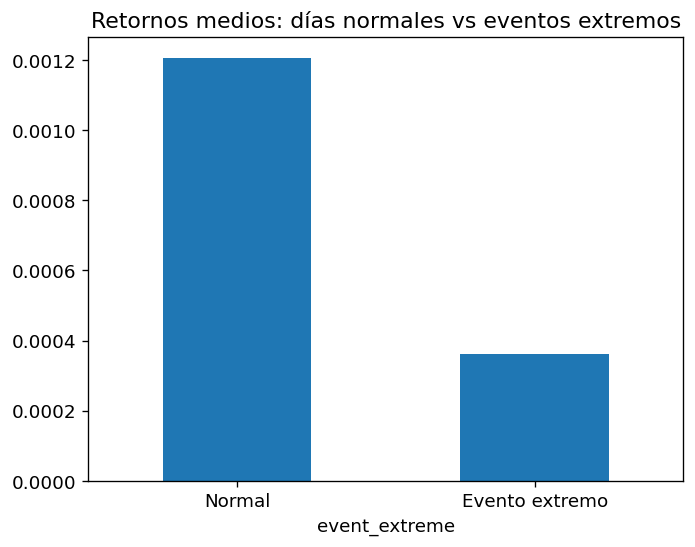

In [24]:
import matplotlib.pyplot as plt

df.groupby('event_extreme')['log_return'].mean().plot(kind='bar')
plt.title('Retornos medios: días normales vs eventos extremos')
plt.xticks([0,1], ['Normal','Evento extremo'], rotation=0)
plt.show()

---
## Sección 6 — Análisis Multi-Horizonte Diario

¿Hasta qué punto el sentimiento de hoy predice la volatilidad de los próximos días?

Entrenamos XGBoost con las mismas 23 features pero cambiando el **horizonte de predicción**:
- **1 día** (t+1): ¿qué pasará mañana?
- **5 días** (t+5): ¿qué pasará la semana que viene?
- **10 días** (t+10): ¿qué pasará en 2 semanas?
- **20 días** (t+20): ¿qué pasará el mes que viene?

Si el sentimiento tiene fecha de caducidad, la importancia de las features de Reddit/GDELT/FinBERT debería **caer** a medida que el horizonte se alarga.

In [25]:
# =============================================================================
# CELDA — Análisis multi-horizonte: ¿cuánto dura la señal del sentimiento?
# =============================================================================
import warnings
warnings.filterwarnings('ignore')

HORIZONTES = [1, 5, 10, 20]
FEATURES_MH = FEATURES.copy()  # las mismas 23 features del modelo principal

resultados_horizonte = []

for h in HORIZONTES:
    print(f"\n{'='*70}")
    print(f"HORIZONTE: {h} día(s) — predecir vol_realized_20d en t+{h}")
    print(f"{'='*70}")
    
    # Crear target desplazado h días
    dfs_h = []
    for ticker in TICKERS:
        dt = df[df['ticker'] == ticker].copy().reset_index(drop=True)
        # Mismas features que el modelo principal
        for lag in range(1, 6):
            dt[f'ret_lag{lag}'] = dt['log_return'].shift(lag)
        dt['vol5d_lag1']        = dt['vol_realized_5d'].shift(1)
        dt['vol_intraday_lag1'] = dt['vol_intraday'].shift(1)
        dt['tone_lag1']         = dt['news_tone_mean'].shift(1)
        dt['n_noticias_lag1']   = dt['news_n_noticias'].shift(1)
        dt['rddt_posts_lag1']   = dt['rddt_n_posts'].shift(1)
        dt['rddt_upvote_lag1']  = dt['rddt_upvote_ratio_mean'].shift(1)
        dt['finbert_score_lag1']= dt['finbert_sentiment_score'].shift(1)
        dt['finbert_neg_lag1']  = dt['finbert_negative_pct'].shift(1)
        dt['finbert_posts_lag1']= dt['finbert_n_posts'].shift(1)
        dt['tone_std_lag1']     = dt['news_tone_std'].shift(1)
        dt['rddt_score_lag1']   = dt['rddt_score_mean'].shift(1)
        dt['finbert_pos_lag1']  = dt['finbert_positive_pct'].shift(1)
        # Target a horizonte h
        dt['target_h'] = dt['vol_realized_20d'].shift(-h)
        dt['ticker_enc'] = le.transform([ticker] * len(dt))
        dfs_h.append(dt)
    
    df_h = pd.concat(dfs_h, ignore_index=True)
    df_h = df_h.dropna(subset=FEATURES_MH + ['target_h'])
    
    # Split temporal 75/5/20
    tr_f, val_f, te_f = [], [], []
    for ticker in TICKERS:
        dt = df_h[df_h['ticker'] == ticker].sort_values('date')
        n = len(dt)
        n_train = int(n * 0.75)
        n_val = int(n * 0.05)
        tr_f.append(dt.iloc[:n_train])
        val_f.append(dt.iloc[n_train:n_train+n_val])
        te_f.append(dt.iloc[n_train+n_val:])
    
    df_tr = pd.concat(tr_f)
    df_va = pd.concat(val_f)
    df_te = pd.concat(te_f)
    
    X_tr, y_tr = df_tr[FEATURES_MH].values, df_tr['target_h'].values
    X_va, y_va = df_va[FEATURES_MH].values, df_va['target_h'].values
    X_te, y_te = df_te[FEATURES_MH].values, df_te['target_h'].values
    
    # Naíf: vol_realized_5d de hoy predice vol_realized_20d en t+h
    naif_pred = df_te['vol5d_lag1'].values  # vol5d disponible en t
    # Asegurar que no hay NaN
    mask_valid = np.isfinite(y_te) & np.isfinite(naif_pred)
    rmse_naif = np.sqrt(np.mean((y_te[mask_valid] - naif_pred[mask_valid])**2))
    
    # XGBoost con early stopping
    modelo_h = xgb.XGBRegressor(
        n_estimators=1000, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        reg_lambda=1.0, reg_alpha=0.1,
        objective='reg:squarederror', random_state=RANDOM_SEED, n_jobs=-1,
        early_stopping_rounds=50
    )
    modelo_h.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    
    y_pred_h = modelo_h.predict(X_te)
    rmse_xgb = np.sqrt(np.mean((y_te - y_pred_h)**2))
    mae_xgb = np.mean(np.abs(y_te - y_pred_h))
    
    # Feature importance
    imp = modelo_h.feature_importances_
    df_imp_h = pd.DataFrame({'feature': FEATURES_MH, 'importance': imp})
    df_imp_h['pct'] = df_imp_h['importance'] / df_imp_h['importance'].sum() * 100
    df_imp_h = df_imp_h.sort_values('importance', ascending=False)
    
    # Clasificar por tipo
    def tipo_feature(f):
        if f.startswith('ret_'): return 'Retornos'
        elif f.startswith('vol') or f == 'vol_intraday_lag1': return 'Volatilidad'
        elif f.startswith('tone') or f.startswith('n_noticias'): return 'GDELT'
        elif f.startswith('rddt'): return 'Reddit'
        elif f.startswith('finbert'): return 'FinBERT'
        elif f in ['month', 'day_of_week']: return 'Temporal'
        elif f == 'ticker_enc': return 'Control'
        else: return 'Otro'
    
    df_imp_h['tipo'] = df_imp_h['feature'].map(tipo_feature)
    imp_por_tipo = df_imp_h.groupby('tipo')['pct'].sum()
    
    sent_total = imp_por_tipo.get('Reddit', 0) + imp_por_tipo.get('GDELT', 0) + imp_por_tipo.get('FinBERT', 0)
    vol_total = imp_por_tipo.get('Volatilidad', 0)
    
    mejora_vs_naif = (rmse_naif - rmse_xgb) / rmse_naif * 100
    
    print(f"  Observaciones test: {len(y_te):,}")
    print(f"  Early stopping: round {modelo_h.best_iteration}")
    print(f"  RMSE Naíf:    {rmse_naif:.4f}")
    print(f"  RMSE XGBoost: {rmse_xgb:.4f}  (mejora: {mejora_vs_naif:+.1f}%)")
    print(f"  MAE XGBoost:  {mae_xgb:.4f}")
    print(f"")
    print(f"  Importancia por fuente:")
    for tipo in ['Volatilidad', 'Reddit', 'GDELT', 'FinBERT', 'Retornos', 'Temporal', 'Control']:
        val = imp_por_tipo.get(tipo, 0)
        print(f"    {tipo:<15} {val:>5.1f}%")
    print(f"    {'SENTIMIENTO':<15} {sent_total:>5.1f}%  (Reddit+GDELT+FinBERT)")
    print(f"")
    print(f"  Top 5 features:")
    for rank, (_, row) in enumerate(df_imp_h.head(5).iterrows(), 1):
        print(f"    {rank}. {row['feature']:<22} {row['pct']:>5.1f}%  ({row['tipo']})")
    
    resultados_horizonte.append({
        'horizonte': h,
        'rmse_naif': round(rmse_naif, 4),
        'rmse_xgb': round(rmse_xgb, 4),
        'mejora_pct': round(mejora_vs_naif, 1),
        'sent_pct': round(sent_total, 1),
        'vol_pct': round(vol_total, 1),
        'early_stop': modelo_h.best_iteration,
        'top1_feature': df_imp_h.iloc[0]['feature'],
        'top1_pct': round(df_imp_h.iloc[0]['pct'], 1)
    })

# Tabla resumen final
print(f"\n\n{'='*80}")
print("TABLA RESUMEN — DEGRADACIÓN POR HORIZONTE (modelos diarios)")
print(f"{'='*80}")
print(f"{'Horizonte':>10} {'RMSE Naíf':>10} {'RMSE XGB':>10} {'Mejora':>8} {'% Sent.':>8} {'% Vol.':>8} {'Top feature':>22}")
print("-" * 80)
for r in resultados_horizonte:
    print(f"{r['horizonte']:>7} días {r['rmse_naif']:>10.4f} {r['rmse_xgb']:>10.4f} {r['mejora_pct']:>+7.1f}% {r['sent_pct']:>7.1f}% {r['vol_pct']:>7.1f}% {r['top1_feature']:>22}")

print(f"\nInterpretación:")
print(f"  - Si '% Sent.' baja con el horizonte → el sentimiento tiene fecha de caducidad")
print(f"  - Si 'Mejora' baja con el horizonte → el modelo pierde ventaja predictiva")
print(f"  - Si '% Vol.' sube con el horizonte → a largo plazo solo la inercia funciona")



HORIZONTE: 1 día(s) — predecir vol_realized_20d en t+1


  Observaciones test: 2,141
  Early stopping: round 51
  RMSE Naíf:    0.1776
  RMSE XGBoost: 0.1178  (mejora: +33.7%)
  MAE XGBoost:  0.0858

  Importancia por fuente:
    Volatilidad      54.5%
    Reddit            7.7%
    GDELT             5.2%
    FinBERT           6.6%
    Retornos          8.5%
    Temporal          3.7%
    Control          13.9%
    SENTIMIENTO      19.4%  (Reddit+GDELT+FinBERT)

  Top 5 features:
    1. vol5d_lag1              41.7%  (Volatilidad)
    2. ticker_enc              13.9%  (Control)
    3. vol_intraday_lag1       12.8%  (Volatilidad)
    4. rddt_upvote_lag1         3.6%  (Reddit)
    5. month                    2.9%  (Temporal)

HORIZONTE: 5 día(s) — predecir vol_realized_20d en t+5


  Observaciones test: 2,135
  Early stopping: round 54
  RMSE Naíf:    0.1728
  RMSE XGBoost: 0.1159  (mejora: +32.9%)
  MAE XGBoost:  0.0834

  Importancia por fuente:
    Volatilidad      55.6%
    Reddit            7.8%
    GDELT             4.8%
    FinBERT           6.7%
    Retornos          7.7%
    Temporal          4.1%
    Control          13.4%
    SENTIMIENTO      19.3%  (Reddit+GDELT+FinBERT)

  Top 5 features:
    1. vol5d_lag1              42.8%  (Volatilidad)
    2. ticker_enc              13.4%  (Control)
    3. vol_intraday_lag1       12.8%  (Volatilidad)
    4. rddt_upvote_lag1         3.4%  (Reddit)
    5. month                    3.1%  (Temporal)

HORIZONTE: 10 día(s) — predecir vol_realized_20d en t+10


  Observaciones test: 2,128
  Early stopping: round 56
  RMSE Naíf:    0.1750
  RMSE XGBoost: 0.1154  (mejora: +34.1%)
  MAE XGBoost:  0.0837

  Importancia por fuente:
    Volatilidad      60.2%
    Reddit            8.2%
    GDELT             4.5%
    FinBERT           6.4%
    Retornos          6.9%
    Temporal          3.9%
    Control           9.9%
    SENTIMIENTO      19.1%  (Reddit+GDELT+FinBERT)

  Top 5 features:
    1. vol5d_lag1              46.2%  (Volatilidad)
    2. vol_intraday_lag1       14.0%  (Volatilidad)
    3. ticker_enc               9.9%  (Control)
    4. rddt_posts_lag1          3.6%  (Reddit)
    5. rddt_upvote_lag1         3.4%  (Reddit)

HORIZONTE: 20 día(s) — predecir vol_realized_20d en t+20


  Observaciones test: 2,118
  Early stopping: round 41
  RMSE Naíf:    0.2358
  RMSE XGBoost: 0.1473  (mejora: +37.5%)
  MAE XGBoost:  0.1091

  Importancia por fuente:
    Volatilidad      19.6%
    Reddit           11.7%
    GDELT             6.4%
    FinBERT          10.2%
    Retornos          9.1%
    Temporal          5.5%
    Control          37.6%
    SENTIMIENTO      28.2%  (Reddit+GDELT+FinBERT)

  Top 5 features:
    1. ticker_enc              37.6%  (Control)
    2. vol_intraday_lag1       14.2%  (Volatilidad)
    3. rddt_posts_lag1          5.8%  (Reddit)
    4. vol5d_lag1               5.4%  (Volatilidad)
    5. finbert_posts_lag1       4.8%  (FinBERT)


TABLA RESUMEN — DEGRADACIÓN POR HORIZONTE (modelos diarios)
 Horizonte  RMSE Naíf   RMSE XGB   Mejora  % Sent.   % Vol.            Top feature
--------------------------------------------------------------------------------
      1 días     0.1776     0.1178   +33.7%    19.4%    54.5%             vol5d_lag1
      5 días  

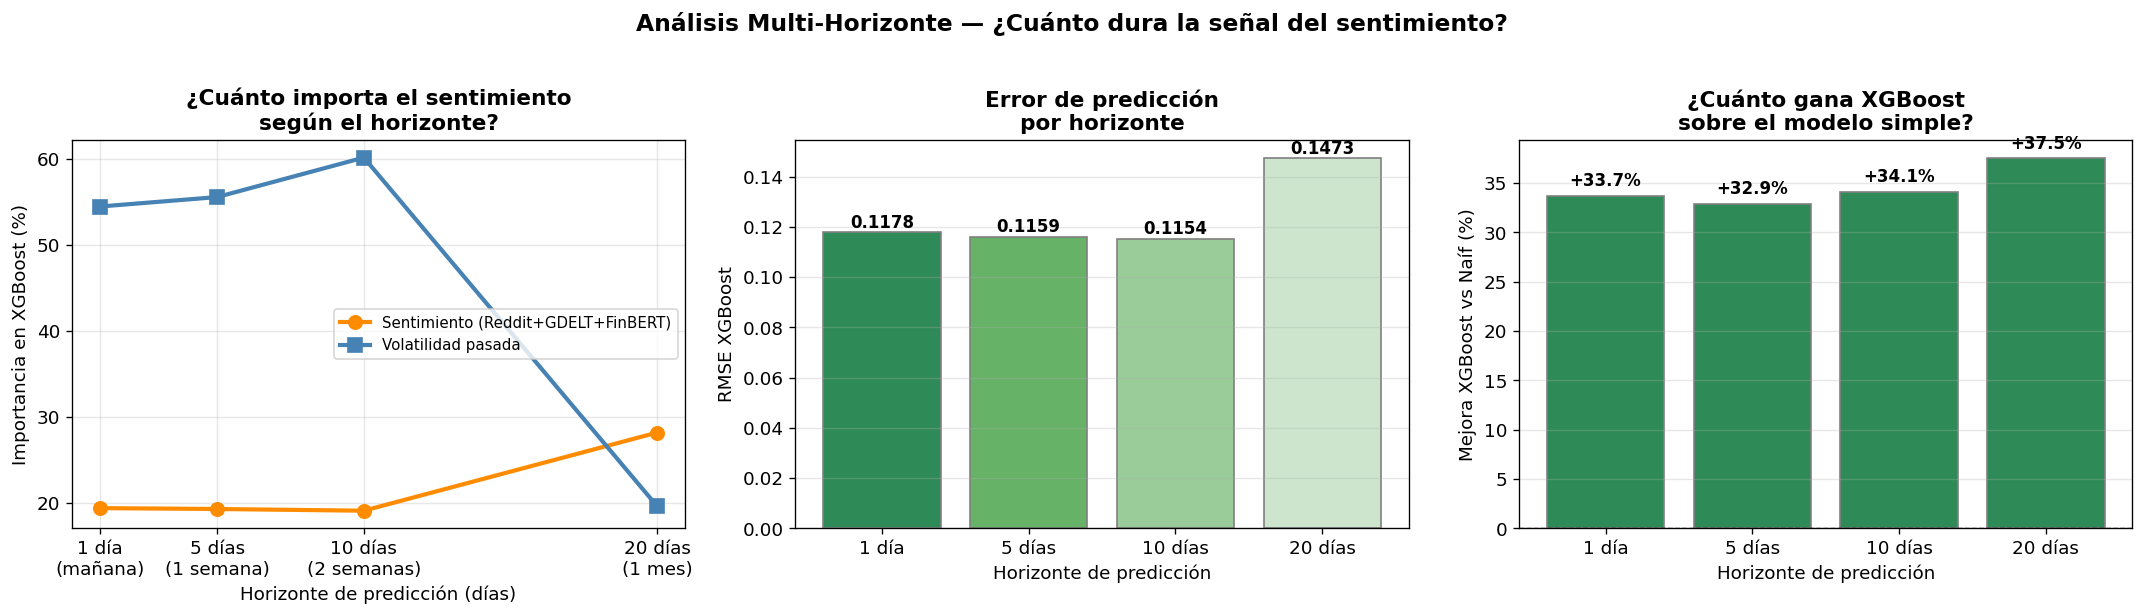

Guardado: modelos_multihorizonte_diario.png


In [26]:
# =============================================================================
# CELDA — Figura: Degradación del sentimiento por horizonte
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

horizontes = [r['horizonte'] for r in resultados_horizonte]
sent_pcts = [r['sent_pct'] for r in resultados_horizonte]
vol_pcts = [r['vol_pct'] for r in resultados_horizonte]
mejoras = [r['mejora_pct'] for r in resultados_horizonte]
rmses = [r['rmse_xgb'] for r in resultados_horizonte]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Importancia sentimiento vs volatilidad
ax1 = axes[0]
ax1.plot(horizontes, sent_pcts, 'o-', color='darkorange', linewidth=2.5, markersize=8, label='Sentimiento (Reddit+GDELT+FinBERT)')
ax1.plot(horizontes, vol_pcts, 's-', color='steelblue', linewidth=2.5, markersize=8, label='Volatilidad pasada')
ax1.set_xlabel('Horizonte de predicción (días)', fontsize=11)
ax1.set_ylabel('Importancia en XGBoost (%)', fontsize=11)
ax1.set_title('¿Cuánto importa el sentimiento\nsegún el horizonte?', fontsize=13, fontweight='bold')
ax1.set_xticks(horizontes)
ax1.set_xticklabels(['1 día\n(mañana)', '5 días\n(1 semana)', '10 días\n(2 semanas)', '20 días\n(1 mes)'])
ax1.legend(fontsize=9, loc='center right')
ax1.grid(True, alpha=0.3)

# Panel 2: RMSE por horizonte
ax2 = axes[1]
ax2.bar(range(len(horizontes)), rmses, color=['seagreen', '#66b266', '#99cc99', '#cce5cc'], edgecolor='gray')
ax2.set_xlabel('Horizonte de predicción', fontsize=11)
ax2.set_ylabel('RMSE XGBoost', fontsize=11)
ax2.set_title('Error de predicción\npor horizonte', fontsize=13, fontweight='bold')
ax2.set_xticks(range(len(horizontes)))
ax2.set_xticklabels(['1 día', '5 días', '10 días', '20 días'])
for i, v in enumerate(rmses):
    ax2.text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
ax2.grid(True, axis='y', alpha=0.3)

# Panel 3: Mejora vs Naíf
ax3 = axes[2]
colors_mejora = ['seagreen' if m > 0 else 'salmon' for m in mejoras]
ax3.bar(range(len(horizontes)), mejoras, color=colors_mejora, edgecolor='gray')
ax3.set_xlabel('Horizonte de predicción', fontsize=11)
ax3.set_ylabel('Mejora XGBoost vs Naíf (%)', fontsize=11)
ax3.set_title('¿Cuánto gana XGBoost\nsobre el modelo simple?', fontsize=13, fontweight='bold')
ax3.set_xticks(range(len(horizontes)))
ax3.set_xticklabels(['1 día', '5 días', '10 días', '20 días'])
ax3.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
for i, v in enumerate(mejoras):
    ax3.text(i, v + (1 if v >= 0 else -2), f'{v:+.1f}%', ha='center', fontsize=10, fontweight='bold')
ax3.grid(True, axis='y', alpha=0.3)

plt.suptitle('Análisis Multi-Horizonte — ¿Cuánto dura la señal del sentimiento?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
ruta = FIGURAS / 'modelos_multihorizonte_diario.png'
plt.savefig(ruta, dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardado: {ruta.name}')
